# Portfolio problem

In [1]:
import math
from pathlib import Path
# import cvxpy as cp
import numpy as np
import pandas as pd
# import scipy as sp
import matplotlib.pyplot as plt
import pickle

from mis_dro.dataset import get_portfolio_returns_df, get_window_of_train_and_test_dataframes
from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *
from mis_dro.portfolio import portfolio_objective_cvxpy, calculate_transaction_cost, apply_transaction_cost_to_last_portfolio_return
from mis_dro.preprocessing import normalise_by_dimension
from mis_dro.metrics import calculate_sharpe_ratio, calculate_sortino_ratio

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=False)

import datetime as dt

In [2]:
# TODO: refactor things a bit

compare_with_original = False
james_windows = True
include_transaction_costs = True

# TODO: set to False outside of testing
use_markowitz_development_script_for_normal_runs = False
use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function = False
use_markowitz_development_script_for_shv_runs_with_transaction_costs_in_cost_function = False

if compare_with_original:
    james_windows = False
    include_transaction_costs = False

In [3]:
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025"
kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016"
# kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio-repeat-parrot"

if compare_with_original:
    kl_experiment_dir_string = "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio-repeat-parrot"

kl_experiment_dir = Path(kl_experiment_dir_string)
assert kl_experiment_dir.exists()

mmc2_dir = Path("/", "dcs", "pg24", "u5674159", "datasets", "misdro", "mmc2")
assert mmc2_dir.exists()

if james_windows:

    # TODO: move other data files into james-data
    experiment_dir_data_dir_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": '/dcs/pg24/u5674159/own-djia-data/_windows_19971001_to_20160427_inclusive_every_12_weeks.pkl',
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": '/dcs/pg24/u5674159/own-djia-data/_windows_19971001_to_20250730_inclusive_every_4_weeks.pkl',
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": "/dcs/pg24/u5674159/own-djia-data/windows_19971001_to_20250702_inclusive_every_4_weeks.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks.pkl"
    }

    experiment_dir_num_test_weeks_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": 12,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": 4,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": 4,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": 13,
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": 13
    }

    experiment_dir_benchmark_from_price_weighted_portfolio_weightings_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks_benchmark_for_price_weighted_portfolio_weightings.pkl",
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/james-data/windows_rebalance_dates_20080220_to_20250430_inclusive_every_13_weeks_benchmark_for_price_weighted_portfolio_weightings.pkl"
    }

    # TODO: move other data files into james-data
    # experiment_dir_djia_level_file_map = {
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2016": "/dcs/pg24/u5674159/own-djia-data/_djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025": "/dcs/pg24/u5674159/own-djia-data/_djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-1997-to-2025-filtration-interpolation": "/dcs/pg24/u5674159/own-djia-data/djia_level_19971001_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/own-djia-data/djia_level_20080220_to_20250730.npy",
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/own-djia-data/djia_level_20080220_to_20250730.npy"
    # }

    experiment_dir_markowitz_file_map_normal_runs_without_transaction_costs_in_results = {
        "ipynb": {
            "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/ipynb_results_for_multiple_lambdas.pkl"
        },
        "slurm": {
            # NOTE: I don't even think the below key and value are comparable as I think they were generated using different Slurm setups
            # "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/results_for_multiple_lambdas.pkl",
            "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/results_for_multiple_lambdas.pkl"
        }
    }

    def get_markowitz_validation_results_with_transaction_costs_in_results(corresponding_kl_experiment_dir_string, from_ipynb, transaction_costs_in_cost_function, validation_type):
        assert corresponding_kl_experiment_dir_string == "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot"
        assert validation_type in ("single_holdout_validation", "rolling_validation_10_folds")
        base_path = "/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/"
        base_path += ("ipynb_" if from_ipynb else "")
        base_path += f"results_for_best_lambdas_from_{validation_type}_with_"
        results = {}
        for ratio_type in ("sharpe", "sortino"):
            path = base_path + ratio_type
            if transaction_costs_in_cost_function:
                path += "_with_transaction_costs_in_cost_function"
            path += ".pkl"
            results[ratio_type] = path
        return results

    # # NOTE that these already have test ratios as well as out_of_sample_cost having transaction costs applied to them already
    # experiment_dir_shv_experiment_dir_map = {
    #     "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": {
    #         "sharpe": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sharpe",
    #         "sortino": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sortino"
    #     }
    # }
    experiment_dir_validation_experiment_dir_map = {
        "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot": {
            "shv": {
                "sharpe": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sharpe",
                "sortino": "/dcs/pg24/u5674159/mis-dro-code/shv-normal-cost-function-sortino"
            },
            "rolling_validation": {
                "sharpe": "/dcs/pg24/u5674159/mis-dro-code/rolling-tv-normal-cost-function-sharpe",
                "sortino": "/dcs/pg24/u5674159/mis-dro-code/rolling-tv-normal-cost-function-sortino"
            }
        }
    }

    def get_kl_dro_validation_results_with_transaction_costs_in_results(corresponding_kl_experiment_dir_string, validation_type, transaction_costs_in_cost_function):
        assert corresponding_kl_experiment_dir_string == "/dcs/pg24/u5674159/mis-dro-code/kl_portfolio_james-2008-to-2025-parrot"
        assert validation_type in ["shv", "rolling_validation"]
        if transaction_costs_in_cost_function:
            assert validation_type == "rolling_validation"
        base_path = "/dcs/pg24/u5674159/mis-dro-code/"
        if validation_type == "shv":
            base_path += "shv-"
        elif validation_type == "rolling_validation":
            base_path += "rolling-tv-"
        else:
            raise NotImplementedError()
        if transaction_costs_in_cost_function:
            base_path += "optimise-transaction-costs-"
        else:
            base_path += "normal-cost-function-"
        results = {}
        for ratio_type in ["sharpe", "sortino"]:
            results[ratio_type] = base_path + ratio_type
        return results

    james_djia_data_path_string = experiment_dir_data_dir_map[kl_experiment_dir_string]
    james_djia_data_path = Path(james_djia_data_path_string)

    num_test_weeks = experiment_dir_num_test_weeks_map[kl_experiment_dir_string]

    james_benchmark_from_price_weighted_portfolio_weightings_map_file = experiment_dir_benchmark_from_price_weighted_portfolio_weightings_map[kl_experiment_dir_string]
    # james_djia_level_file = experiment_dir_djia_level_file_map[kl_experiment_dir_string]

    james_markowitz_results_file_normal_runs_without_transaction_costs = experiment_dir_markowitz_file_map_normal_runs_without_transaction_costs_in_results["slurm" if not use_markowitz_development_script_for_normal_runs else "ipynb"][kl_experiment_dir_string]

    dict_for_markowitz_results_files_shv_with_tcosts_in_results = get_markowitz_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function, False, "single_holdout_validation")
    dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results = get_markowitz_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function, False, "rolling_validation_10_folds")
    dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results_and_cost_function = get_markowitz_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, use_markowitz_development_script_for_validation_runs_without_transaction_costs_in_cost_function, True, "rolling_validation_10_folds")

    risk_free_rates_file = "/dcs/pg24/u5674159/mis-dro-code/james-data/risk_free_returns_weekly_2008-02-27_to_2025-07-30_inclusive.pkl"

    kl_validation_experiment_dirs_map = {}
    kl_validation_experiment_dirs_map_tcost_optimisation = {}
    for validation_type in ("shv", "rolling_validation"):
        kl_validation_experiment_dirs_map[validation_type] = get_kl_dro_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, validation_type, False)
        if validation_type == "rolling_validation":
            kl_validation_experiment_dirs_map_tcost_optimisation[validation_type] = get_kl_dro_validation_results_with_transaction_costs_in_results(kl_experiment_dir_string, validation_type, True)

In [4]:
dgp = "DowJones"

if james_windows:
    with open(james_benchmark_from_price_weighted_portfolio_weightings_map_file, 'rb') as f:
        benchmark = pickle.load(f)
    prev_stock_figi_list = []
    prev_portfolio_weighting = []
    out_of_sample_costs = []

    out_of_sample_costs_with_weighting_drift = []
    # NOTE (pwd): initialise out_of_sample_costs_with_weighting_drift as empty list

    for i, window in enumerate(benchmark):
        out_of_sample_costs_for_this_window = window["out_of_sample_cost"]

        out_of_sample_costs_for_this_window_with_weighting_drift = window["oos_portfolio_returns_with_weighting_drift"]
        # NOTE (pwd): initialise out_of_sample_costs_for_this_window_with_weighting_drift as window["oos_portfolio_returns_with_weighting_drift"]

        if include_transaction_costs:
            weighting = window["weighting"]
            stock_figi_list = [col.split("_")[0] for col in weighting.index]
            transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, weighting)

            # prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, weighting
            # NOTE (pwd): above, replace weighting with window["drifted_weighting"]
            prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, window["drifted_weighting"]

            # out_of_sample_costs_for_this_window.iloc[0] -= transaction_cost
            # NOTE (pwd): replace the above line of code with a modification of the final element of out_of_sample_costs_with_weighting_drift, not simply subtracting the transaction cost but remembering the interaction term as well, and add a condition that the line is only run if i != 0
            if i != 0:
                out_of_sample_costs_with_weighting_drift[-1] = apply_transaction_cost_to_last_portfolio_return(out_of_sample_costs_with_weighting_drift[-1], transaction_cost)

        out_of_sample_costs += list(out_of_sample_costs_for_this_window)

        # NOTE (pwd): do the same as above but updating out_of_sample_costs_with_weighting_drift using out_of_sample_costs_for_this_window_with_weighting_drift
        out_of_sample_costs_with_weighting_drift += list(out_of_sample_costs_for_this_window_with_weighting_drift)

    index_returns_np = np.array(out_of_sample_costs)
    index_returns_df = pd.DataFrame(index_returns_np)

    # NOTE (pwd): create index_returns_np_with_weighting_drift using out_of_sample_costs_with_weighting_drift
    # NOTE (pwd): create index_returns_df_with_weighting_drift using index_returns_np_with_weighting_drift
    index_returns_np_with_weighting_drift = np.array(out_of_sample_costs_with_weighting_drift)
    index_returns_df_with_weighting_drift = pd.DataFrame(index_returns_np_with_weighting_drift)
else:
    index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Index_Returns", header=None)

if james_windows:
    with open(james_djia_data_path, 'rb') as f:
        windows = pickle.load(f)
else:
    returns_df = get_portfolio_returns_df(mmc2_dir, dgp)

if james_windows:
    with open(risk_free_rates_file, "rb") as f:
        risk_free_rates = pickle.load(f)

In [5]:
if james_windows:
    experiment_name = ExperimentName.kl_portfolio_james
    experiment_name_shv = ExperimentName.tv_kl_portfolio_james
    experiment_name_rolling_validation = experiment_name_shv + "_rolling_validation"
else:
    experiment_name = ExperimentName.kl_portfolio
    print(experiment_name.value)
    
kl_results_df = pd.read_csv(kl_experiment_dir / "results.csv", index_col=["uuid", "replication"])

if james_windows:

    # ratio_type_to_kl_shv_results_df_map = {ratio_type: pd.read_csv(Path(experiment_dir_path) / "results.csv", index_col=["uuid", "replication"]) for ratio_type, experiment_dir_path in kl_shv_experiment_dirs.items()}
    ratio_type_to_kl_validation_results_df_maps = {}
    ratio_type_to_kl_validation_results_df_maps_tcost_optimisation = {}
    for experiment_dirs_map, results_map in [
        [kl_validation_experiment_dirs_map, ratio_type_to_kl_validation_results_df_maps],
        [kl_validation_experiment_dirs_map_tcost_optimisation, ratio_type_to_kl_validation_results_df_maps_tcost_optimisation]
    ]:
        for validation_type, kl_experiment_dirs in experiment_dirs_map.items():
            results_map[validation_type] = {ratio_type: pd.read_csv(Path(experiment_dir_path) / "results.csv", index_col=["uuid", "replication"]) for ratio_type, experiment_dir_path in kl_experiment_dirs.items()}

# mmd_results_df = pd.read_csv(mmd_experiment_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = kl_results_df.loc[kl_results_df["algorithm"].isin(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])]
# all_results_df = pd.concat([kl_results_df, mmd_results_df])

if james_windows:
    for results_map in [
        ratio_type_to_kl_validation_results_df_maps, 
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                # TODO: maybe refactor the below RHS with similar code above
                map[ratio_type] = kl_results_df.loc[(kl_results_df["total_validation_posterior_time"].notna()) & (kl_results_df["algorithm"].isin(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"]))]

print(all_results_df["algorithm"].unique())
# TODO: refactor
for results_map in [
    ratio_type_to_kl_validation_results_df_maps,
    ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
]:
    for map in results_map.values():
        for _, df in map.items():
            print(df["algorithm"].unique())

['kl_dro_bas' 'kl_bdro' 'kl_pp' 'kl_empirical']
['kl_dro_bas' 'kl_bdro' 'kl_pp' 'kl_empirical']
['kl_dro_bas' 'kl_bdro' 'kl_pp' 'kl_empirical']
['kl_dro_bas' 'kl_bdro' 'kl_pp' 'kl_empirical']
['kl_dro_bas' 'kl_bdro' 'kl_pp' 'kl_empirical']
['kl_dro_bas' 'kl_bdro' 'kl_pp' 'kl_empirical']
['kl_dro_bas' 'kl_bdro' 'kl_pp' 'kl_empirical']


In [6]:
# NOTE filter by DGP
if james_windows:
    filter_dgp = "james"
    dataset = "james"
else:
    filter_dgp = "DowJones"
    dataset = "portfolio"

results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)

if james_windows:

    for results_map in [
        ratio_type_to_kl_validation_results_df_maps,
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                map[ratio_type] = preprocess_results_df(kl_results_df, filter_dgp, dataset=dataset, temporal_validation=True)

# NOTE filter out when log_partition_constant G is less than epsilon
# results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

# NOTE we always want the same number of test observations and replications
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
assert np.isclose(results_df["num_replications"].var(), 0)
num_replications = results_df["num_replications"].unique()[0]
if james_windows:
    for results_map in [
        ratio_type_to_kl_validation_results_df_maps,
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                # TODO: maybe refactor with similar code above
                assert np.isclose(kl_results_df["num_test_observations"].var(), 0)
                assert num_test_observations == kl_results_df["num_test_observations"].unique()[0]
                assert np.isclose(kl_results_df["num_replications"].var(), 0)
                assert num_replications == kl_results_df["num_replications"].unique()[0]

# NOTE if you are running PP with multiple num_likelihood_samples then you will need the below line
results_df = results_df.loc[((results_df["algorithm"] == "kl_pp") & (results_df["num_likelihood_samples"] == 3600)) | (results_df["algorithm"] != "kl_pp")]
if james_windows:
    for results_map in [
        ratio_type_to_kl_validation_results_df_maps,
        ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
    ]:
        # TODO: probably refactor below with above
        for map in results_map.values():
            for ratio_type, kl_results_df in map.items():
                map[ratio_type] = kl_results_df.loc[((kl_results_df["algorithm"] == "kl_pp") & (kl_results_df["num_likelihood_samples"] == 3600)) | (kl_results_df["algorithm"] != "kl_pp")]

In [7]:
agg_df = get_agg_df(results_df, ["algorithm", "epsilon", "inference"])
for results_map in [
    ratio_type_to_kl_validation_results_df_maps,
    ratio_type_to_kl_validation_results_df_maps_tcost_optimisation
]:
    for map in results_map.values():
        for ratio_type, df in map.items():
            print(ratio_type, df)
        ratio_type_to_kl_validation_agg_df_map = {ratio_type: get_agg_df(df, ["algorithm", "inference"], temporal_validation=True) for ratio_type, df in map.items()}
        for ratio_type, df in ratio_type_to_kl_validation_agg_df_map.items():
            print(ratio_type, df)

sharpe                                                                                            solution  \
uuid                                 replication                                                      
e8727f4d-51ff-4e22-90e4-82e25c621d51 0            [0.03397069324985495, 0.021680839256498594, 0....   
                                     1            [0.0756028519007124, 9.936334646325848e-09, 0....   
                                     2            [1.4231990910270988e-08, 6.2484364765229236e-0...   
                                     3            [1.7879049327283444e-09, 1.4315966005054603e-0...   
                                     4            [3.578595265677988e-08, 2.8186528326899013e-08...   
...                                                                                             ...   
adca9178-a69d-44dd-bf88-ea9ce71be8a6 65           [1.0305495919152269e-06, 3.2217627715774934e-0...   
                                     66           [1.3316699115284

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function mean at 0x7facf82e4f40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function std at 0x7facf82e5080> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function mean at 0x7facf82e4f40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dr

In [8]:
if james_windows:
    with open(james_markowitz_results_file_normal_runs_without_transaction_costs, "rb") as f:
        markowitz_results_james_normal_runs = pickle.load(f)

    markowitz_results_shv_with_tcosts_in_results = {}
    markowitz_results_rolling_validation_with_tcosts_in_results = {}
    markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function = {}
    for ratio_type in (
        "sharpe",
        "sortino"
    ):
        with open(dict_for_markowitz_results_files_shv_with_tcosts_in_results[ratio_type], "rb") as f:
            results_for_ratio_type = pickle.load(f)
            markowitz_results_shv_with_tcosts_in_results[ratio_type] = results_for_ratio_type
        with open(dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results[ratio_type], "rb") as f:
            results_for_ratio_type = pickle.load(f)
            markowitz_results_rolling_validation_with_tcosts_in_results[ratio_type] = results_for_ratio_type
        with open(dict_for_markowitz_results_files_rolling_validation_with_tcosts_in_results_and_cost_function[ratio_type], "rb") as f:
            results_for_ratio_type = pickle.load(f)
            markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function[ratio_type] = results_for_ratio_type

In [9]:
# fig, ax = plt.subplots(figsize=(8,6))
# df = agg_df
# df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
# TODO (James): the above just uses out_of_sample_var/mean, not oos_var/mean_with_weighting_drift
# for (algorithm, inference), group_df in df.groupby(["algorithm", "inference"]):
#     if algorithm == "kl_dro_bas":
#         local_log_partition_constant = True
#         offset=0.00003
#         special_epsilons = [0.00001, 0.001, 0.01, 1.0]
#     else:
#         local_log_partition_constant = False
#         offset=0.00003
#         special_epsilons = [0.00001, 0.0005, 0.005, 1.0]
#     mean_variance_plot(
#         ax, group_df, is_labelled=True, offset=offset, alpha=1.0,
#         **algorithm_inference_style(algorithm, inference, label_inference=False),
#         special_epsilons=special_epsilons,
#         add_log_partition_function=local_log_partition_constant, minimise=False
#     )
#     #  log_partition_constant=local_log_partition_constant
# # handles, labels = ax.get_legend_handles_labels()
# # order = [1,0]
# # ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# ax.legend(fontsize=12)
# ax.set_xlabel("Out-of-sample variance")
# ax.set_ylabel("Out-of-sample mean")
# # ax.set_xlim(agg_df["out_of_sample_var"].min(), agg_df["out_of_sample_var"].max())
# # ax.set_ylim(agg_df["out_of_sample_mean"].min(), agg_df["out_of_sample_mean"].min())
# TODO (James): the above just uses out_of_sample_var/mean, not oos_var/mean_with_weighting_drift
# handles, labels = ax.get_legend_handles_labels()
# algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value]
# order = [list(labels).index(a) for a in algorithm_order]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
# # fig.show()
# # NOTE: this does not include transaction costs
# # fig.savefig(f"{kl_experiment_dir_string}/{experiment_name}_mean_var_{filter_dgp}_{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf", bbox_inches="tight")

In [10]:
if compare_with_original:

    mean_variance_plot_data_dict = {}
    current_label = None
    lines = ax.get_lines()
    for i in range(len(lines)):
        line = lines[i]
        label = line.get_label()
        if label != "_nolegend_":
            current_label = label
        elif i == len(lines) - 1 or lines[i + 1].get_label() != "_nolegend_":
            x, y = line.get_xdata(), line.get_ydata()
            mean_variance_plot_data_dict[current_label] = {"x": x, "y": y}

    directory_with_old_plot_data_for_replication = "/dcs/pg24/u5674159/mis-dro-code/james_old_plot_data_for_replication"
    with open(f"{directory_with_old_plot_data_for_replication}/mean_variance_bdro_dro-bas_real_data.pkl", "rb") as f:
        old_mean_variance_plot_data_dict = pickle.load(f)

    assert old_mean_variance_plot_data_dict.keys() == mean_variance_plot_data_dict.keys()
    for key in old_mean_variance_plot_data_dict:
        for coord in "x", "y":
            np.array_equal(old_mean_variance_plot_data_dict[key][coord], mean_variance_plot_data_dict[key][coord])

In [11]:
# TODO: refactor some of what's in this function with some of what's in the other "include_transaction_costs_in*" functions
def include_transaction_costs_in_dro_results(results_df, dro_algorithms_for_figure, kl_epsilon_list, num_replications, james_djia_data_path_string):
    for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
        if algorithm not in dro_algorithms_for_figure or epsilon not in kl_epsilon_list:
            continue
        prev_stock_figi_list = []
        prev_portfolio_weighting = []
        for i in range(num_replications):

            # portfolio_returns_this_period = group_df["out_of_sample_cost"].values[i]
            # NOTE (pwd): above, replace out_of_sample_cost with oos_portfolio_returns_with_weighting_drift.
            portfolio_returns_this_period = group_df["oos_portfolio_returns_with_weighting_drift"].values[i]

            # TODO: this whole thing with the use of get_window_of_train_and_test_dataframes is a bit of a fudge--the stock IDs should be saved along with the other results. Moreover, I don't know why I appended _{window index} to each of the FIGIs in the first place, so undo that and get rid of the splitting done below.
            stock_figi_list = [col.split("_")[0] for col in get_window_of_train_and_test_dataframes(i, james_djia_data_path_string)[0].columns]
            portfolio_weighting = group_df["solution"].values[i]
            transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, portfolio_weighting)

            # prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, portfolio_weighting
            # NOTE (pwd): above, replace portfolio_weighting with group_df["drifted_weighting"].values[i]
            prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, group_df["drifted_weighting"].values[i]

            # portfolio_returns_this_period[0] -= transaction_cost
            # NOTE (pwd): replace the line above with a line modifying the last element of results_df.at[group_df.index[i-1], "oos_portfolio_returns_with_weighting_drift"], if that's even how you modify that, remembering the interaction term in how the transaction cost is applied, and doing this only if i != 0
            if i != 0:
                results_df.at[group_df.index[i-1], "oos_portfolio_returns_with_weighting_drift"][-1] = apply_transaction_cost_to_last_portfolio_return(results_df.at[group_df.index[i-1], "oos_portfolio_returns_with_weighting_drift"][-1], transaction_cost)

            # results_df.at[group_df.index[i], "out_of_sample_cost"] = portfolio_returns_this_period
            # NOTE (pwd): above, replace out_of_sample_cost with oos_portfolio_returns_with_weighting_drift
            results_df.at[group_df.index[i], "oos_portfolio_returns_with_weighting_drift"] = portfolio_returns_this_period


def include_transaction_costs_in_markowitz_results(markowitz_results_james_normal_runs_without_transaction_costs, markowitz_lambdas, james_djia_data_path_string):
    for item in markowitz_results_james_normal_runs_without_transaction_costs.items():
        risk_aversion_value, windows = item
        if risk_aversion_value not in markowitz_lambdas:
            continue
        prev_stock_figi_list = []
        prev_portfolio_weighting = []
        for i, window in enumerate(windows):

            # out_of_sample_costs_for_window = list(window["out_of_sample_cost"])
            # NOTE (pwd): above, replace out_of_sample_cost with oos_portfolio_returns_with_weighting_drift
            out_of_sample_costs_for_window_with_weighting_drift = list(window["oos_portfolio_returns_with_weighting_drift"])

            # NOTE (pwd): rename used occurences of out_of_sample_costs_for_window to out_of_sample_costs_for_window_with_weighting_drift in occurrences in this function

            stock_figi_list = [col.split("_")[0] for col in get_window_of_train_and_test_dataframes(i, james_djia_data_path_string)[0].columns]
            portfolio_weighting = window["portfolio_weighting"]
            transaction_cost = calculate_transaction_cost(prev_stock_figi_list, prev_portfolio_weighting, stock_figi_list, portfolio_weighting)

            # prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, portfolio_weighting
            # NOTE (pwd): above, replace portfolio_weighting with window["drifted_weighting"]
            prev_stock_figi_list, prev_portfolio_weighting = stock_figi_list, window["drifted_weighting"]

            # out_of_sample_costs_for_window[0] -= transaction_cost
            # NOTE (pwd): replace the line above with a line modifying the last element of markowitz_results_james_normal_runs_without_transaction_costs[risk_aversion_value][i-1]["oos_portfolio_returns_with_weighting_drift"], if that's even how you modify that, remembering the interaction term in how the transaction cost is applied, and doing this only if i != 0
            if i != 0:
                markowitz_results_james_normal_runs_without_transaction_costs[risk_aversion_value][i-1]["oos_portfolio_returns_with_weighting_drift"][-1] = apply_transaction_cost_to_last_portfolio_return(markowitz_results_james_normal_runs_without_transaction_costs[risk_aversion_value][i-1]["oos_portfolio_returns_with_weighting_drift"][-1], transaction_cost)

            # NOTE: originally a numpy array or pandas series, now a python list
            # markowitz_results_james_normal_runs_without_transaction_costs[risk_aversion_value][i]["out_of_sample_cost"] = out_of_sample_costs_for_window_with_weighting_drift
            # NOTE (pwd): above, replace out_of_sample_cost with oos_portfolio_returns_with_weighting_drift
            markowitz_results_james_normal_runs_without_transaction_costs[risk_aversion_value][i]["oos_portfolio_returns_with_weighting_drift"] = out_of_sample_costs_for_window_with_weighting_drift

In [12]:
def calculate_dro_results_to_plot(dro_algorithms_for_figure, kl_algorithms, results_df, kl_epsilon_list, mmd_epsilon_list, weeks_for_risk_adjusted_metrics, num_replications, risk_free_rates, num_test_weeks, james_windows):

    dro_figure_data = {algorithm: {} for algorithm in dro_algorithms_for_figure}

    for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
        is_mmd_experiment = algorithm in ("dro_bas_mmd", "empirical_mmd")
        is_kl_experiment = algorithm in kl_algorithms

        if james_windows:
            if algorithm not in dro_algorithms_for_figure:
                continue

        if (is_kl_experiment and epsilon in kl_epsilon_list) or (is_mmd_experiment and epsilon in mmd_epsilon_list):
            cost_list = []

            # NOTE (pwd): add cost_list_with_weighting_drift
            cost_list_with_weighting_drift = []
            
            sortino_ratios = []
            sharpe_ratios = []
            for i in range(num_replications):
                out_of_sample_returns_this_period = group_df["out_of_sample_cost"].values[i]
                out_of_sample_returns_this_period_with_weighting_drift = group_df["oos_portfolio_returns_with_weighting_drift"].values[i]
                # NOTE (pwd): create out_of_sample_returns_this_period_with_weighting_drift using oos_portfolio_returns_with_weighting_drift

                cost_list += out_of_sample_returns_this_period
                cost_list_with_weighting_drift += out_of_sample_returns_this_period_with_weighting_drift
                # NOTE (pwd): update cost_list_with_weighting_drift with out_of_sample_returns_this_period_with_weighting_drift

                weekly_risk_free_rates = risk_free_rates[:(i+1)*num_test_weeks]

                # params_for_ratio = {"weekly_portfolio_returns": cost_list, "period_in_weeks": weeks_for_risk_adjusted_metrics}
                # NOTE (pwd): in the above, replace cost_list with cost_list_with_weighting_drift
                params_for_ratio = {"weekly_portfolio_returns": cost_list_with_weighting_drift, "period_in_weeks": weeks_for_risk_adjusted_metrics}

                sharpe_ratios.append(calculate_sharpe_ratio(**params_for_ratio, weekly_risk_free_rates=weekly_risk_free_rates))
                sortino_ratios.append(calculate_sortino_ratio(**params_for_ratio, weekly_targets=weekly_risk_free_rates))

            dro_portfolio_returns = np.array(cost_list)
            dro_portfolio_returns_with_weighting_drift = np.array(cost_list_with_weighting_drift)
            # NOTE (pwd): create dro_portfolio_returns_with_weighting_drift and set it to np.array(cost_list_with_weighting_drift)

            results = {
                "sharpe_ratios": sharpe_ratios,
                "sortino_ratios": sortino_ratios,
                "dro_portfolio_returns": dro_portfolio_returns,
                "dro_portfolio_returns_with_weighting_drift": dro_portfolio_returns_with_weighting_drift
                # NOTE (pwd): "dro_portfolio_returns_with_weighting_drift": dro_portfolio_returns_with_weighting_drift
            }

            dro_figure_data[algorithm][epsilon] = results

    return dro_figure_data

def get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_map, num_replications):
    validation_kl_dro_figure_data = {}
    for ratio_type, results_df in ratio_type_to_kl_validation_results_df_map.items():
        validation_kl_dro_figure_data_for_ratio = {algorithm: {} for algorithm in dro_algorithms_for_figure}
        for algorithm, group_df in results_df.groupby("algorithm"):
            if algorithm not in dro_algorithms_for_figure:
                continue
            cost_list = []
            ratio_list = []
            for i in range(num_replications):

                # cost_list += group_df["out_of_sample_cost"].values[i]
                # NOTE (pwd): above, replace out_of_sample_cost with oos_portfolio_returns_with_weighting_drift
                cost_list += group_df["oos_portfolio_returns_with_weighting_drift"].values[i]

                ratio_list.append(group_df[ratio_type].values[i])
            validation_kl_dro_portfolio_returns = np.array(cost_list)
            results = {
                "portfolio_returns": validation_kl_dro_portfolio_returns,
                "ratios": ratio_list
            }
            validation_kl_dro_figure_data_for_ratio[algorithm] = results
        validation_kl_dro_figure_data[ratio_type] = validation_kl_dro_figure_data_for_ratio
    return validation_kl_dro_figure_data

def calculate_markowitz_normal_runs_results_to_plot(markowitz_results_james_normal_runs, markowitz_lambdas, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):

    markowitz_figure_data = {}

    for item in markowitz_results_james_normal_runs.items():
        risk_aversion_value, windows = item
        if risk_aversion_value not in markowitz_lambdas:
            continue

        markowitz_cost_list = []
        markowitz_cost_list_with_weighting_drift = []
        # NOTE (pwd): add markowitz_cost_list_with_weighting_drift

        markowitz_sharpe_ratios = []
        markowitz_sortino_ratios = []
        for i, window in enumerate(windows):

            # TODO: note that, below, using list constructor because, if it doesn't go through include_transaction_costs_in_markowitz_results first, the out of sample costs in markowitz_results_james_normal_runs may not be Python lists
            out_of_sample_costs_for_window = list(window["out_of_sample_cost"])
            out_of_sample_costs_for_window_with_weighting_drift = list(window["oos_portfolio_returns_with_weighting_drift"])
            # NOTE (pwd): create out_of_sample_costs_for_window_with_weighting_drift using oos_portfolio_returns_with_weighting_drift

            markowitz_cost_list += out_of_sample_costs_for_window
            markowitz_cost_list_with_weighting_drift += out_of_sample_costs_for_window_with_weighting_drift
            # NOTE (pwd): update markowitz_cost_list_with_weighting_drift with out_of_sample_costs_for_window_with_weighting_drift

            weekly_risk_free_rates = risk_free_rates[:(i+1)*num_test_weeks]

            # params_for_ratio = {"weekly_portfolio_returns": markowitz_cost_list, "period_in_weeks": weeks_for_risk_adjusted_metrics}
            # NOTE (pwd): in the above, replace markowitz_cost_list with markowitz_cost_list_with_weighting_drift
            params_for_ratio = {"weekly_portfolio_returns": markowitz_cost_list_with_weighting_drift, "period_in_weeks": weeks_for_risk_adjusted_metrics}

            markowitz_sharpe_ratios.append(calculate_sharpe_ratio(**params_for_ratio, weekly_risk_free_rates=weekly_risk_free_rates))
            markowitz_sortino_ratios.append(calculate_sortino_ratio(**params_for_ratio, weekly_targets=weekly_risk_free_rates))

        markowitz_portfolio_returns = np.array(markowitz_cost_list)
        markowitz_portfolio_returns_with_weighting_drift = np.array(markowitz_cost_list_with_weighting_drift)
        # NOTE (pwd): create markowitz_portfolio_returns_with_weighting_drift and set it to np.array(markowitz_cost_list_with_weighting_drift)

        results = {
            "markowitz_portfolio_returns": markowitz_portfolio_returns,
            "markowitz_portfolio_returns_with_weighting_drift": markowitz_portfolio_returns_with_weighting_drift,
            # NOTE (pwd): "markowitz_portfolio_returns_with_weighting_drift": markowitz_portfolio_returns_with_weighting_drift,

            "markowitz_sharpe_ratios": markowitz_sharpe_ratios,
            "markowitz_sortino_ratios": markowitz_sortino_ratios,
        }

        markowitz_figure_data[risk_aversion_value] = results

    return markowitz_figure_data

def calculate_price_weighted_results_to_plot(index_returns_df, index_returns_df_with_weighting_drift, num_time_windows, num_test_weeks, risk_free_rates, weeks_for_risk_adjusted_metrics):
# NOTE (pwd): insert index_returns_df_with_weighting_drift as the 2nd parameter below, without removing any existing parameters
# def calculate_price_weighted_results_to_plot(index_returns_df, num_time_windows, num_test_weeks, risk_free_rates, weeks_for_risk_adjusted_metrics):

    price_weighted_portfolio_returns = list(index_returns_df.values)
    price_weighted_portfolio_returns_with_weighting_drift = list(index_returns_df_with_weighting_drift.values)
    # NOTE (pwd): price_weighted_portfolio_returns_with_weighting_drift = list(index_returns_df_with_weighting_drift.values)

    sharpe_ratios = []
    sortino_ratios = []
    for i in range(num_time_windows):
        weekly_risk_free_rates = risk_free_rates[:(i+1)*num_test_weeks]

        # params_for_ratio = {"weekly_portfolio_returns": price_weighted_portfolio_returns[:(i+1)*num_test_weeks], "period_in_weeks": weeks_for_risk_adjusted_metrics}
        # NOTE (pwd): replace price_weighted_portfolio_returns above with price_weighted_portfolio_returns_with_weighting_drift
        params_for_ratio = {"weekly_portfolio_returns": price_weighted_portfolio_returns_with_weighting_drift[:(i+1)*num_test_weeks], "period_in_weeks": weeks_for_risk_adjusted_metrics}

        sharpe_ratios.append(calculate_sharpe_ratio(**params_for_ratio, weekly_risk_free_rates=weekly_risk_free_rates))
        sortino_ratios.append(calculate_sortino_ratio(**params_for_ratio, weekly_targets=weekly_risk_free_rates))

    price_weighted_figure_data = {
        "price_weighted_portfolio_returns": price_weighted_portfolio_returns,
        "price_weighted_portfolio_returns_with_weighting_drift": price_weighted_portfolio_returns_with_weighting_drift,
        # NOTE (pwd): "price_weighted_portfolio_returns_with_weighting_drift": price_weighted_portfolio_returns_with_weighting_drift,

        "price_weighted_sharpe_ratios": sharpe_ratios,
        "price_weighted_sortino_ratios": sortino_ratios
    }

    return price_weighted_figure_data

In [13]:
def calculate_potential_ratio_results(ratio, num_replications, hyperparameter_list, dro_results_df, markowitz_results_dict, algorithm, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):

    highest_ratios = []
    best_hyperparameters = []
    running_portfolio_returns = []
    for i in range(num_replications):
        highest_ratio_this_window = -float('inf')
        best_hyperparameter_this_window = None
        best_running_portfolio_returns = None
        for hyperparameter in hyperparameter_list:
            if algorithm == "markowitz":
                # TODO: note that, below, using list constructor because, if it doesn't go through include_transaction_costs_in_markowitz_results first, the out of sample costs in markowitz_results_james_normal_runs may not have been Python lists

                # portfolio_returns_this_window_under_this_hyperparameter = list(markowitz_results_dict[hyperparameter][i]["out_of_sample_cost"])
                # NOTE (pwd): above, replace out_of_sample_cost with oos_portfolio_returns_with_weighting_drift
                portfolio_returns_this_window_under_this_hyperparameter = list(markowitz_results_dict[hyperparameter][i]["oos_portfolio_returns_with_weighting_drift"])

            else:

                # portfolio_returns_this_window_under_this_hyperparameter = dro_results_df[(dro_results_df["algorithm"] == algorithm) & (dro_results_df["epsilon"] == hyperparameter)]["out_of_sample_cost"].values[i]
                # NOTE (pwd): above, replace out_of_sample_cost with oos_portfolio_returns_with_weighting_drift
                portfolio_returns_this_window_under_this_hyperparameter = dro_results_df[(dro_results_df["algorithm"] == algorithm) & (dro_results_df["epsilon"] == hyperparameter)]["oos_portfolio_returns_with_weighting_drift"].values[i]

            running_portfolio_returns_under_this_hyperparameter = running_portfolio_returns + portfolio_returns_this_window_under_this_hyperparameter
            ratio_calculator = {"sharpe": calculate_sharpe_ratio, "sortino": calculate_sortino_ratio}[ratio]
            ratio_this_window_under_this_hyperparameter = ratio_calculator(running_portfolio_returns_under_this_hyperparameter, risk_free_rates[:(i+1)*num_test_weeks], weeks_for_risk_adjusted_metrics)
            if ratio_this_window_under_this_hyperparameter > highest_ratio_this_window:
                highest_ratio_this_window = ratio_this_window_under_this_hyperparameter
                best_hyperparameter_this_window = hyperparameter
                best_running_portfolio_returns = running_portfolio_returns_under_this_hyperparameter
        highest_ratios.append(highest_ratio_this_window)
        best_hyperparameters.append(best_hyperparameter_this_window)
        running_portfolio_returns = best_running_portfolio_returns
    return {"highest_ratios": highest_ratios, "best_hyperparameters": best_hyperparameters}

def calculate_potential_dro_ratio_results(dro_algorithms_for_figure, num_replications, kl_epsilon_list, results_df, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):

    potential_results = {}

    for ratio in ("sharpe", "sortino"):

        potential_results_for_ratio = {}

        for algorithm in dro_algorithms_for_figure:

            potential_results_for_ratio[algorithm] = calculate_potential_ratio_results(ratio, num_replications, kl_epsilon_list, results_df, None, algorithm, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

        potential_results[ratio] = potential_results_for_ratio

    return potential_results

def calculate_potential_markowitz_ratio_results(num_replications, markowitz_lambdas, markowitz_results_james_normal_runs, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics):
    
    potential_results = {}

    for ratio in ("sharpe", "sortino"):

        potential_results[ratio] = calculate_potential_ratio_results(ratio, num_replications, markowitz_lambdas, None, markowitz_results_james_normal_runs, "markowitz", risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

    return potential_results

In [14]:
def process_markowitz_validation_results_to_plot(markowitz_results_james_validation_with_transaction_costs):

    processed_results = {}

    for ratio_type, windows in markowitz_results_james_validation_with_transaction_costs.items():
        processed_results[ratio_type] = [window[ratio_type] for window in windows]

    return processed_results

In [15]:
if james_windows:
    num_time_windows = len(windows)
else:
    num_time_windows = math.floor((len(returns_df) - IN_SAMPLE_TIME_WINDOW) / OUT_OF_SAMPLE_TIME_WINDOW)
    last_week = len(index_returns_df.iloc[IN_SAMPLE_TIME_WINDOW:])

kl_epsilon_list = [
    0.00001,
    0.001,
    1
]
mmd_epsilon_list = [0.0001, 0.01, 0.2]
kl_algorithms = ("kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical")

dro_algorithms_for_figure = (
    "kl_bdro",
    "kl_pp",
    "kl_dro_bas",
    "kl_empirical"
)

weeks_for_risk_adjusted_metrics = 156
rebalance_periods_for_risk_adjusted_metrics = int(weeks_for_risk_adjusted_metrics / num_test_weeks)

markowitz_lambdas = (
    0.5,
    5,
    50,
    500
)

if include_transaction_costs:

    include_transaction_costs_in_dro_results(results_df, dro_algorithms_for_figure, kl_epsilon_list, num_replications, james_djia_data_path_string)
    include_transaction_costs_in_markowitz_results(markowitz_results_james_normal_runs, markowitz_lambdas, james_djia_data_path_string)
    # NOTE: the results in ratio_type_to_kl_validation_results_df_maps, specifically the out_of_sample_cost details, already feature transaction costs

if james_windows:

    # price_weighted_figure_data = calculate_price_weighted_results_to_plot(index_returns_df, num_time_windows, num_test_weeks, risk_free_rates, weeks_for_risk_adjusted_metrics)
    # NOTE (pwd): insert index_returns_df_with_weighting_drift as 2nd argument above (don't replace aught though)
    price_weighted_figure_data = calculate_price_weighted_results_to_plot(index_returns_df, index_returns_df_with_weighting_drift, num_time_windows, num_test_weeks, risk_free_rates, weeks_for_risk_adjusted_metrics)

    dro_figure_data = calculate_dro_results_to_plot(dro_algorithms_for_figure, kl_algorithms, results_df, kl_epsilon_list, mmd_epsilon_list, weeks_for_risk_adjusted_metrics, num_replications, risk_free_rates, num_test_weeks, james_windows)
    
    shv_dro_figure_data = get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_maps["shv"], num_replications)
    potential_dro_ratio_results = calculate_potential_dro_ratio_results(dro_algorithms_for_figure, num_replications, kl_epsilon_list, results_df, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)
    rolling_validation_dro_figure_data = get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_maps["rolling_validation"], num_replications)
    rolling_validation_dro_figure_data_tcost_optimisation = get_validation_kl_dro_results_to_plot(dro_algorithms_for_figure, ratio_type_to_kl_validation_results_df_maps_tcost_optimisation["rolling_validation"], num_replications)

    markowitz_normal_runs_figure_data = calculate_markowitz_normal_runs_results_to_plot(markowitz_results_james_normal_runs, markowitz_lambdas, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)

    markowitz_shv_figure_data = process_markowitz_validation_results_to_plot(markowitz_results_shv_with_tcosts_in_results)
    potential_markowitz_ratio_results = calculate_potential_markowitz_ratio_results(num_replications, markowitz_lambdas, markowitz_results_james_normal_runs, risk_free_rates, num_test_weeks, weeks_for_risk_adjusted_metrics)
    markowitz_rolling_validation_figure_data = process_markowitz_validation_results_to_plot(markowitz_results_rolling_validation_with_tcosts_in_results)
    markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data = process_markowitz_validation_results_to_plot(markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function)

    # markowitz_shv_figure_data_with_tcosts_in_cost_function = process_markowitz_validation_results_to_plot(markowitz_results_shv_with_tcosts_in_results_and_cost_function)

In [16]:
def _get_oos_weeks():
    start_date = dt.date(2008, 2, 27)   # NOTE: first test date
    end_date = dt.date(2025, 7, 30) # NOTE: last test date
    oos_weeks = []
    current = start_date
    while current <= end_date:
        oos_weeks.append(current)
        current += dt.timedelta(weeks=1)
    return oos_weeks

def get_x_data_for_all_ratios(weeks_for_risk_adjusted_metrics, num_test_weeks):
    oos_weeks = _get_oos_weeks()
    return oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

def remove_extra_data_from_start_for_equal_bands(array, num_bands):
    num_extra_start_elements = len(array) % num_bands
    return array[num_extra_start_elements:]

def get_band_x_data(all_ratios_x_data, num_bands):
    ratios_x_data = remove_extra_data_from_start_for_equal_bands(all_ratios_x_data, num_bands)
    band_num_elements = len(ratios_x_data) // num_bands
    band_x_data = []
    for i in range(num_bands):
        start = i * band_num_elements
        if band_num_elements % 2 == 1:
            middle = ratios_x_data[start + band_num_elements // 2]
        else:
            left_middle = ratios_x_data[start + band_num_elements // 2 - 1]
            right_middle = ratios_x_data[start + band_num_elements // 2]
            middle = left_middle + (right_middle - left_middle) / 2
        band_x_data.append(middle)
    return band_x_data

# TODO: looks like this could use get_jitters but haven't set that up as I want to retire the below and use get_jitters instead of passing around the below dictionaries
def map_hyperparameters_to_jitter(band_x_data):
    jitter_step = (band_x_data[1] - band_x_data[0]) * 0.05
    return {
        "dro": {
            0.00001: -jitter_step,
            0.001: dt.timedelta(0),
            1: jitter_step
        },
        "markowitz": {
            0.5: -1.5 * jitter_step,
            5: -0.5 * jitter_step,
            50: 0.5 * jitter_step,
            500: 1.5 * jitter_step
        }
    }

def remove_ratios_with_too_short_period(ratios, rebalance_periods_for_risk_adjusted_metrics):
    return ratios[rebalance_periods_for_risk_adjusted_metrics-1:]

def get_band_means_and_stds(ratios, num_bands):
    mean_list = []
    std_list = []
    for i in range(num_bands):
        band_elements = ratios[i * num_bands: (i + 1) * num_bands]
        mean_list.append(sum(band_elements) / len(band_elements))
        std_list.append(np.std(band_elements, ddof=1))    # Sample STD
    return {"mean_list": mean_list, "std_list": std_list}

def print_non_band_means_and_stds(ratios_for_band_pre_banding, identifier):
    mean = sum(ratios_for_band_pre_banding) / len(ratios_for_band_pre_banding)
    std = np.std(ratios_for_band_pre_banding, ddof=1)
    print(f"{identifier}: before banding, mean is {'{:.4f}'.format(mean)} and sample std is {'{:.4f}'.format(std)}")

def get_band_figure_data_for_all_ratios_including_short_period_ones(all_ratios, rebalance_periods_for_risk_adjusted_metrics, num_bands, identifier):
    ratios = remove_ratios_with_too_short_period(all_ratios, rebalance_periods_for_risk_adjusted_metrics)
    ratios = remove_extra_data_from_start_for_equal_bands(ratios, num_bands)
    print_non_band_means_and_stds(ratios, identifier)
    return get_band_means_and_stds(ratios, num_bands)

def get_band_price_weighted_figure_data(price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands):
    band_price_weighted_figure_data = {}
    for ratio_key, all_ratios in price_weighted_figure_data.items():

        if ratio_key not in ["price_weighted_sharpe_ratios", "price_weighted_sortino_ratios"]:
            continue
        band_price_weighted_figure_data[ratio_key] = get_band_figure_data_for_all_ratios_including_short_period_ones(all_ratios, rebalance_periods_for_risk_adjusted_metrics, num_bands, ratio_key)

    return band_price_weighted_figure_data

def _get_band_figure_data_for_alg(algorithm_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands, algorithm):
    band_algorithm_figure_data = {}
    for hyperparameter, hyperparameter_figure_data_for_algorithm in algorithm_figure_data.items():

        band_hyperparameter_figure_data_for_algorithm = {}
        for ratio_key, all_ratios in hyperparameter_figure_data_for_algorithm.items():

            band_hyperparameter_figure_data_for_algorithm[ratio_key] = get_band_figure_data_for_all_ratios_including_short_period_ones(all_ratios, rebalance_periods_for_risk_adjusted_metrics, num_bands, f"{algorithm} hyp. value {hyperparameter} {ratio_key}")
        
        band_algorithm_figure_data[hyperparameter] = band_hyperparameter_figure_data_for_algorithm

    return band_algorithm_figure_data

def get_band_dro_figure_data(dro_figure_data, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands):
    band_dro_figure_data = {}
    for algorithm, algorithm_figure_data in dro_figure_data.items():

        if algorithm not in dro_algorithms_for_figure:
            continue
        band_dro_figure_data[algorithm] = _get_band_figure_data_for_alg(algorithm_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands, algorithm)
    
    return band_dro_figure_data

def get_band_markowitz_figure_data(markowitz_normal_runs_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands):
    return _get_band_figure_data_for_alg(markowitz_normal_runs_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands, "markowitz")

# TODO: this is the same as get_band_validation_dro_figure_data but with one different parameter and using "highest_ratios" rather than "ratios"
def get_band_potential_dro_ratio_results(potential_dro_ratio_results, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands):
    band_potential_dro_ratio_results = {}
    for ratio_type, data_for_ratio_type in potential_dro_ratio_results.items():

        band_data_for_ratio_type = {}
        for algorithm in data_for_ratio_type.keys():

            if algorithm not in dro_algorithms_for_figure:
                continue
            all_ratios = data_for_ratio_type[algorithm]["highest_ratios"]
            band_data_for_ratio_type[algorithm] = {"highest_ratios": get_band_figure_data_for_all_ratios_including_short_period_ones(all_ratios, rebalance_periods_for_risk_adjusted_metrics, num_bands, f"{algorithm} potential {ratio_type}")}

        band_potential_dro_ratio_results[ratio_type] = band_data_for_ratio_type

    return band_potential_dro_ratio_results

def get_band_potential_markowitz_ratio_results(potential_markowitz_ratio_results, rebalance_periods_for_risk_adjusted_metrics, num_bands):

    # potential_markowitz_ratios = potential_markowitz_ratio_results[ratio_type]["highest_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    band_potential_markowitz_ratio_results = {}
    for ratio_type in potential_markowitz_ratio_results.keys():

        all_ratios = potential_markowitz_ratio_results[ratio_type]["highest_ratios"]

        band_potential_markowitz_ratio_results[ratio_type] = {"highest_ratios": get_band_figure_data_for_all_ratios_including_short_period_ones(all_ratios, rebalance_periods_for_risk_adjusted_metrics, num_bands, f"markowitz potential {ratio_type}")}

    return band_potential_markowitz_ratio_results

def get_band_validation_dro_figure_data(validation_dro_figure_data, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands, validation_type):
    band_validation_dro_figure_data = {}
    for ratio_type, data_for_ratio_type in validation_dro_figure_data.items():

        band_data_for_ratio_type = {}
        for algorithm in data_for_ratio_type.keys():

            if algorithm not in dro_algorithms_for_figure:
                continue
            all_ratios = data_for_ratio_type[algorithm]["ratios"]
            band_data_for_ratio_type[algorithm] = {"ratios": get_band_figure_data_for_all_ratios_including_short_period_ones(all_ratios, rebalance_periods_for_risk_adjusted_metrics, num_bands, f"{algorithm} {validation_type} {ratio_type}")}

        band_validation_dro_figure_data[ratio_type] = band_data_for_ratio_type

    return band_validation_dro_figure_data

def get_band_markowitz_validation_figure_data(markowitz_validation_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands, validation_type):
    band_markowitz_validation_figure_data = {}
    for ratio_type, all_ratios in markowitz_validation_figure_data.items():

        band_markowitz_validation_figure_data[ratio_type] = get_band_figure_data_for_all_ratios_including_short_period_ones(all_ratios, rebalance_periods_for_risk_adjusted_metrics, num_bands, f"markowitz {validation_type} {ratio_type}")

    return band_markowitz_validation_figure_data

plot_bands = True
if plot_bands:
    num_bands = 3
    dro_hyperparameters_to_marker = {
        0.00001: "o",
        0.001: "^",
        1: "s"
    }
    markowitz_hyperparameters_to_marker = {
        0.5: "o",
        5: "^",
        50: "s",
        500: "*"
    }
    all_ratios_x_data = get_x_data_for_all_ratios(weeks_for_risk_adjusted_metrics, num_test_weeks)
    assert num_bands <= len(all_ratios_x_data)
    band_x_data = get_band_x_data(all_ratios_x_data, num_bands)
    jitter_maps = map_hyperparameters_to_jitter(band_x_data)
    dro_hyperparameters_to_jitter = jitter_maps["dro"]
    markowitz_hyperparameters_to_jitter = jitter_maps["markowitz"]
    # For all y data below, getting band plotting data:
        # 1. Remove extra data (for equal band width) at the beginning after the typical removal that is done for the ratios (i.e. the removal of the first rebalance_periods_for_risk_adjusted_metrics-1 elements)
        # 2. Calculate the means
        # 3. Calculate the STDs
    band_price_weighted_figure_data = get_band_price_weighted_figure_data(price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands)
    band_dro_figure_data = get_band_dro_figure_data(dro_figure_data, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands)
    band_markowitz_normal_runs_figure_data = get_band_markowitz_figure_data(markowitz_normal_runs_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands)
    band_potential_dro_ratio_results = get_band_potential_dro_ratio_results(potential_dro_ratio_results, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands)
    band_potential_markowitz_ratio_results = get_band_potential_markowitz_ratio_results(potential_markowitz_ratio_results, rebalance_periods_for_risk_adjusted_metrics, num_bands)
    band_shv_dro_figure_data = get_band_validation_dro_figure_data(shv_dro_figure_data, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands, "shv")
    band_markowitz_shv_figure_data = get_band_markowitz_validation_figure_data(markowitz_shv_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands, "shv")
    band_rolling_validation_dro_figure_data = get_band_validation_dro_figure_data(rolling_validation_dro_figure_data, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands, "rtv")
    band_markowitz_rolling_validation_figure_data = get_band_markowitz_validation_figure_data(markowitz_rolling_validation_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands, "rtv")
    band_rolling_validation_dro_figure_data_tcost_optimisation = get_band_validation_dro_figure_data(rolling_validation_dro_figure_data_tcost_optimisation, dro_algorithms_for_figure, rebalance_periods_for_risk_adjusted_metrics, num_bands, "rtv tcost optimisation")
    band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data = get_band_markowitz_validation_figure_data(markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, rebalance_periods_for_risk_adjusted_metrics, num_bands, "rtv tcost optimisation")

else:

    band_price_weighted_figure_data = None
    band_dro_figure_data = None
    band_markowitz_normal_runs_figure_data = None
    band_potential_dro_ratio_results = None
    band_potential_markowitz_ratio_results = None
    band_shv_dro_figure_data = None
    band_markowitz_shv_figure_data = None
    band_rolling_validation_dro_figure_data = None
    band_markowitz_rolling_validation_figure_data = None
    band_rolling_validation_dro_figure_data_tcost_optimisation = None
    band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data = None

    # TODO: complete lsit of Nones

price_weighted_sharpe_ratios: before banding, mean is 0.1132 and sample std is 0.0513
price_weighted_sortino_ratios: before banding, mean is 0.1648 and sample std is 0.0816
kl_bdro hyp. value 1e-05 sharpe_ratios: before banding, mean is 0.0841 and sample std is 0.0705
kl_bdro hyp. value 1e-05 sortino_ratios: before banding, mean is 0.1279 and sample std is 0.1071
kl_bdro hyp. value 1e-05 dro_portfolio_returns: before banding, mean is 0.0028 and sample std is 0.0343
kl_bdro hyp. value 1e-05 dro_portfolio_returns_with_weighting_drift: before banding, mean is 0.0024 and sample std is 0.0344
kl_bdro hyp. value 0.001 sharpe_ratios: before banding, mean is 0.0938 and sample std is 0.0552
kl_bdro hyp. value 0.001 sortino_ratios: before banding, mean is 0.1352 and sample std is 0.0851
kl_bdro hyp. value 0.001 dro_portfolio_returns: before banding, mean is 0.0022 and sample std is 0.0239
kl_bdro hyp. value 0.001 dro_portfolio_returns_with_weighting_drift: before banding, mean is 0.0019 and samp

In [142]:
def _set_up_plot(oos_weeks, y_type, min_y, max_y):

    fig, ax = plt.subplots(figsize=(16,9))

    first_training_week = min(oos_weeks) - dt.timedelta(weeks=52)
    ax.set_xlim(first_training_week, max(oos_weeks) + dt.timedelta(weeks=52))
    ax.set_xlabel("Date")

    # ylabel = f"Out-of-sample {y_type}"
    ylabel = y_type

    ax.set_ylabel(ylabel)
    ax.set_ylim(min_y, max_y)

    opts = {"color": "black", "linewidth": 1, "zorder": 0, "alpha": 0.4}
    ax.axhline(0, **opts)
    ax.axvline(min(oos_weeks), **opts)

    return fig, ax

def _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs):
    figure_save_file = f"{kl_experiment_dir_string}/{experiment_name}_{plot_type}_"
    if include_transaction_costs:
        figure_save_file += "transaction_costs_"
    figure_save_file += f"{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"
    return figure_save_file

def _get_figure_save_file_just_markowitz(plot_type, include_transaction_costs):

    figure_save_file = f"/dcs/pg24/u5674159/mis-dro-code/markowitz_results_james/{plot_type}_"
    if include_transaction_costs:
        figure_save_file += "transaction_costs_in_results"
    figure_save_file += f"{dt.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.pdf"

    return figure_save_file

def _plot_price_weighted_data(ax, x_data, price_weighted_data, plot_bands=None):
    ax.plot(
        x_data,
        price_weighted_data,
        label="Price-Weighted",
        color="#a65628",
        linestyle="dashed" if plot_bands else "solid",
        marker="o" if plot_bands else None,
        markersize=8 if plot_bands else 0
    )

def _plot_band_borders(ax, band_x_data):

    # NOTE: the below relies on the true midpoint being found in sub-sampling for band_x_data (i.e. if each band has an even number of data, finding the midpoint of the middle two timestamps), each band having the same number of data to sub-sample and each timestamp in band_x_data initially being equally spaced

    opts = {"color": "black", "linestyle": "dashed", "zorder": 0, "alpha": 0.4}
    half_step = (band_x_data[1] - band_x_data[0]) / 2
    ax.axvline(band_x_data[0] - half_step, **opts)
    for timestamp in band_x_data:
        ax.axvline(timestamp + half_step, **opts)

def _plot_stds(ax, x_list, y_list, std_list, color):
    for x, y, std in zip(x_list, y_list, std_list):
        ax.vlines(x, y - std, y + std, colors=color)

def _plot_y_data_for_one_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, algorithm, hyperparameter_y_data_map, hyperparameter_list, algorithm_name_pretty, algorithm_color, hyperparameter_to_linestyle, save, min_y, max_y, figure_save_file, y_type, oos_weeks, x_data, plot_bands=False, band_x_data=None, band_hyperparameter_y_data_map=None, hyperparameters_to_marker=None, hyperparameters_to_jitter=None):

    fig, ax = _set_up_plot(oos_weeks, y_type, min_y, max_y)

    if plot_bands:

        _plot_band_borders(ax, band_x_data)

        hyperparameter_band_x_data_with_jitter = {
            hyperparameter: [x + hyperparameters_to_jitter[hyperparameter] for x in band_x_data]
            for hyperparameter in hyperparameter_list
        }

        for hyperparameter in hyperparameter_list:
            _plot_stds(
                ax,
                hyperparameter_band_x_data_with_jitter[hyperparameter],
                band_hyperparameter_y_data_map[hyperparameter]["mean_list"],
                band_hyperparameter_y_data_map[hyperparameter]["std_list"],
                algorithm_color
            )

    for hyperparameter in hyperparameter_list:
        
        if algorithm == "kl_dro_bas":
            label = algorithm_name_pretty + " ($\epsilon = G +" + str(hyperparameter) + "$)"
        elif algorithm == "markowitz":
            label = algorithm_name_pretty + f" (λ = {hyperparameter})"
        else:
            label = algorithm_name_pretty + f" ($\epsilon = {hyperparameter}$)"

        if plot_bands:
            marker = hyperparameters_to_marker[hyperparameter]
            if marker == "*":
                markersize = 14
            else:
                markersize = 8
        else:
            marker = None
            markersize = 0

        ax.plot(
            hyperparameter_band_x_data_with_jitter[hyperparameter] if plot_bands else x_data,
            band_hyperparameter_y_data_map[hyperparameter]["mean_list"] if plot_bands else hyperparameter_y_data_map[hyperparameter],
            label=label,
            alpha=0.8,
            color=algorithm_color,
            linestyle="dashed" if plot_bands else hyperparameter_to_linestyle[hyperparameter],
            marker=marker,
            markersize=markersize
        )

    if price_weighted_figure_data is not None:
        if plot_bands:
            raise NotImplementedError()
        _plot_price_weighted_data(
            ax,
            x_data,
            price_weighted_figure_data
        )

    ax.legend(ncol=2) 
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def plot_cumulative_returns_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, kl_experiment_dir_string, experiment_name, algorithm, dro_figure_data, kl_epsilon_list, AlgorithmName, AlgorithmColor, include_transaction_costs, save, min_y, max_y, has_weighting_drift):
# NOTE (pwd): add a boolean parameter here called has_weighting_drift
# def plot_cumulative_returns_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, kl_experiment_dir_string, experiment_name, algorithm, dro_figure_data, kl_epsilon_list, AlgorithmName, AlgorithmColor, include_transaction_costs, save, min_y, max_y):

    plot_type = f"avg_returns_{algorithm}"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)

    algorithm_figure_data = dro_figure_data[algorithm]

    # hyperparameter_y_data_map = {epsilon: np.cumsum(algorithm_figure_data[epsilon]["dro_portfolio_returns"]) for epsilon in algorithm_figure_data}
    # NOTE (pwd): if has_weighting_drift, use dro_portfolio_returns_with_weighting_drift instead of the above key
    hyperparameter_y_data_map = {epsilon: np.cumsum(algorithm_figure_data[epsilon][("dro_portfolio_returns_with_weighting_drift" if has_weighting_drift else "dro_portfolio_returns")]) for epsilon in algorithm_figure_data}

    algorithm_name_pretty = AlgorithmName[algorithm].value

    algorithm_color = AlgorithmColor[algorithm].value

    hyperparameter_to_linestyle = {
        0.00001: "dotted",
        0.001: "dashed",
        1.0: "solid"
    }

    oos_weeks = _get_oos_weeks()

    _plot_y_data_for_one_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(np.cumsum(price_weighted_figure_data[("price_weighted_portfolio_returns_with_weighting_drift" if has_weighting_drift else "price_weighted_portfolio_returns")]), algorithm, hyperparameter_y_data_map, kl_epsilon_list, algorithm_name_pretty, algorithm_color, hyperparameter_to_linestyle, save, min_y, max_y, figure_save_file, "Cumulative Out-of-Sample Weekly Portfolio Return", oos_weeks, oos_weeks)
    # NOTE (pwd): below, if has_weighting_drift, you're gonna want price_weighted_portfolio_returns_with_weighting_drift instead of price_weighted_portfolio_returns
    # _plot_y_data_for_one_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(np.cumsum(price_weighted_figure_data["price_weighted_portfolio_returns"]), algorithm, hyperparameter_y_data_map, kl_epsilon_list, algorithm_name_pretty, algorithm_color, hyperparameter_to_linestyle, save, min_y, max_y, figure_save_file, "cumulative return", oos_weeks, oos_weeks)

def plot_cumulative_returns_for_markowitz_under_different_hyperparameters_against_portfolio_weighted_approach(include_transaction_costs, markowitz_normal_runs_figure_data, price_weighted_figure_data, markowitz_lambdas, save, min_y, max_y, has_weighting_drift):
# NOTE (pwd): add a boolean parameter here called has_weighting_drift
# def plot_cumulative_returns_for_markowitz_under_different_hyperparameters_against_portfolio_weighted_approach(include_transaction_costs, markowitz_normal_runs_figure_data, price_weighted_figure_data, markowitz_lambdas, save, min_y, max_y):

    figure_save_file = _get_figure_save_file_just_markowitz("markowitz", include_transaction_costs)

    # hyperparameter_y_data_map = {risk_aversion: np.cumsum(markowitz_normal_runs_figure_data[risk_aversion]["markowitz_portfolio_returns"]) for risk_aversion in markowitz_normal_runs_figure_data}
    # NOTE (pwd): if has_weighting_drift, use markowitz_portfolio_returns_with_weighting_drift instead of the above key
    hyperparameter_y_data_map = {risk_aversion: np.cumsum(markowitz_normal_runs_figure_data[risk_aversion][("markowitz_portfolio_returns_with_weighting_drift" if has_weighting_drift else "markowitz_portfolio_returns")]) for risk_aversion in markowitz_normal_runs_figure_data}

    hyperparameter_to_linestyle = {
        0.5: "dotted",
        5: "dashdot",
        50: "dashed",
        500: "solid",
    }

    oos_weeks = _get_oos_weeks()

    _plot_y_data_for_one_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(np.cumsum(price_weighted_figure_data[("price_weighted_portfolio_returns_with_weighting_drift" if has_weighting_drift else "price_weighted_portfolio_returns")]), "markowitz", hyperparameter_y_data_map, markowitz_lambdas, "Markowitz", "blue", hyperparameter_to_linestyle, save, min_y, max_y, figure_save_file, "Cumulative Out-of-Sample Weekly Portfolio Return", oos_weeks, oos_weeks)
    # NOTE (pwd): below, if has_weighting_drift, you're gonna want price_weighted_portfolio_returns_with_weighting_drift instead of price_weighted_portfolio_returns
    # _plot_y_data_for_one_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(np.cumsum(price_weighted_figure_data["price_weighted_portfolio_returns"]), "markowitz", hyperparameter_y_data_map, markowitz_lambdas, "Markowitz", "blue", hyperparameter_to_linestyle, save, min_y, max_y, figure_save_file, "cumulative return", oos_weeks, oos_weeks)

def plot_ratios_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(ratio_type, algorithm, kl_experiment_dir_string, experiment_name, include_transaction_costs, dro_figure_data, rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, weeks_for_risk_adjusted_metrics, num_test_weeks, kl_epsilon_list, save, min_y, max_y, plot_bands=False, band_x_data=None, band_dro_figure_data=None, dro_hyperparameters_to_marker=None, dro_hyperparameters_to_jitter=None):

    # TODO: always plot with transaction costs applied to results

    plot_type = f"{ratio_type.capitalize()}_ratios_{algorithm}"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)

    algorithm_figure_data = dro_figure_data[algorithm]
    hyperparameter_y_data_map = {epsilon: algorithm_figure_data[epsilon][f"{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:] for epsilon in algorithm_figure_data}

    algorithm_name_pretty = AlgorithmName[algorithm].value

    algorithm_color = AlgorithmColor[algorithm].value

    hyperparameter_to_linestyle = {
        0.00001: "dotted",
        0.001: "dashed",
        1.0: "solid"
    }

    oos_weeks = _get_oos_weeks()

    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    if plot_bands:
        band_algorithm_figure_data = band_dro_figure_data[algorithm]
        band_hyperparameter_y_data_map = {epsilon: band_algorithm_figure_data[epsilon][f"{ratio_type}_ratios"] for epsilon in band_algorithm_figure_data}
        y_type = f"Mean Out-of-Sample {ratio_type.capitalize()} Ratio (± Standard Deviation)"
    else:
        band_hyperparameter_y_data_map = None
        y_type = f"Out-of-Sample {ratio_type.capitalize()} Ratio"

    _plot_y_data_for_one_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(None, algorithm, hyperparameter_y_data_map, kl_epsilon_list, algorithm_name_pretty, algorithm_color, hyperparameter_to_linestyle, save, min_y, max_y, figure_save_file, y_type, oos_weeks, x_data, plot_bands=plot_bands, band_x_data=band_x_data, band_hyperparameter_y_data_map=band_hyperparameter_y_data_map, hyperparameters_to_marker=dro_hyperparameters_to_marker, hyperparameters_to_jitter=dro_hyperparameters_to_jitter)

def plot_ratios_for_markowitz_under_different_hyperparameters_against_portfolio_weighted_approach(ratio_type, include_transaction_costs, markowitz_normal_runs_figure_data, rebalance_periods_for_risk_adjusted_metrics, weeks_for_risk_adjusted_metrics, num_test_weeks, lambda_list, save, min_y, max_y, plot_bands=False, band_x_data=None, band_markowitz_normal_runs_figure_data=None, markowitz_hyperparameters_to_marker=None, markowitz_hyperparameters_to_jitter=markowitz_hyperparameters_to_jitter):

    # TODO: always plot with transaction costs applied to results

    figure_save_file = _get_figure_save_file_just_markowitz(f"markowitz_{ratio_type.capitalize()}_ratio", include_transaction_costs)

    hyperparameter_y_data_map = {risk_aversion: markowitz_normal_runs_figure_data[risk_aversion][f"markowitz_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:] for risk_aversion in markowitz_normal_runs_figure_data}

    hyperparameter_to_linestyle = {
        0.5: "dotted",
        5: "dashdot",
        50: "dashed",
        500: "solid",
    }

    oos_weeks = _get_oos_weeks()

    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    if plot_bands:
        y_type = f"Mean Out-of-Sample {ratio_type.capitalize()} Ratio (± Standard Deviation)"
    else:
        y_type = f"Out-of-Sample {ratio_type.capitalize()} Ratio"

    band_hyperparameter_y_data_map = {risk_aversion: band_markowitz_normal_runs_figure_data[risk_aversion][f"markowitz_{ratio_type}_ratios"] for risk_aversion in band_markowitz_normal_runs_figure_data}

    _plot_y_data_for_one_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(None, "markowitz", hyperparameter_y_data_map, lambda_list, "Markowitz", "blue", hyperparameter_to_linestyle, save, min_y, max_y, figure_save_file, y_type, oos_weeks, x_data, plot_bands=plot_bands, band_x_data=band_x_data, band_hyperparameter_y_data_map=band_hyperparameter_y_data_map, hyperparameters_to_marker=markowitz_hyperparameters_to_marker, hyperparameters_to_jitter=markowitz_hyperparameters_to_jitter)

def get_jitters(num_jitters, band_x_data, jitter_step_fraction_of_band_width):
    jitter_step = (band_x_data[1] - band_x_data[0]) * jitter_step_fraction_of_band_width
    jitter_central_offset = 0.5 if num_jitters % 2 == 0 else 0
    return [
        dt.timedelta(0) if m == 0 else m * jitter_step
        for m in (i - num_jitters // 2 + jitter_central_offset for i in range(num_jitters))
    ]

def plot_ratios_for_best_hyperparameters_against_price_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, dro_figure_data, markowitz_normal_runs_figure_data, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, algorithm_best_hyperparameter_map, AlgorithmName, AlgorithmColor, save, plot_bands=False, band_x_data=None, band_dro_figure_data=None, band_markowitz_normal_runs_figure_data=None, dro_hyperparameters_to_marker=None, markowitz_hyperparameters_to_marker=None, band_price_weighted_figure_data=None):

    # TODO: remember, the graph might not have the correct best hyperparameter value for each optimiser

    oos_weeks = _get_oos_weeks()

    if plot_bands:
        y_type = f"Mean Out-of-Sample {ratio_type.capitalize()} Ratio (± Standard Deviation)"
    else:
        y_type = f"Out-of-Sample {ratio_type.capitalize()} Ratio"

    fig, ax = _set_up_plot(oos_weeks, y_type, min_y, max_y)

    plot_type = f"{ratio_type.capitalize()}_ratios_under_single_best_hyperparameter_for_each_optimiser"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)

    x_data = band_x_data if plot_bands else oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    dro_algorithm_y_data_map = {}
    dro_algorithms_stds_map = {}
    for algorithm, algorithm_figure_data in (band_dro_figure_data if plot_bands else dro_figure_data).items():
        epsilon = algorithm_best_hyperparameter_map[algorithm]
        all_y_data_for_epsilon_for_alg = algorithm_figure_data[epsilon][f"{ratio_type}_ratios"]
        if plot_bands:
            dro_algorithm_y_data_map[algorithm] = all_y_data_for_epsilon_for_alg["mean_list"]
            dro_algorithms_stds_map[algorithm] = all_y_data_for_epsilon_for_alg["std_list"]
        else:
            dro_algorithm_y_data_map[algorithm] = all_y_data_for_epsilon_for_alg[rebalance_periods_for_risk_adjusted_metrics-1:]

    risk_aversion = algorithm_best_hyperparameter_map["markowitz"]
    all_ratios_for_markowitz_best_risk_aversion = (band_markowitz_normal_runs_figure_data if plot_bands else markowitz_normal_runs_figure_data)[risk_aversion][f"markowitz_{ratio_type}_ratios"]
    if plot_bands:
        markowitz_y_data = all_ratios_for_markowitz_best_risk_aversion["mean_list"]
        markowitz_stds = all_ratios_for_markowitz_best_risk_aversion["std_list"]
    else:
        markowitz_y_data = all_ratios_for_markowitz_best_risk_aversion[rebalance_periods_for_risk_adjusted_metrics-1:]

    if plot_bands:
        price_weighted_y_data = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["mean_list"]
        price_weighted_stds = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["std_list"]
    else:
        price_weighted_y_data = price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    dro_algorithms_x_data = {algorithm: x_data for algorithm in dro_algorithm_y_data_map.keys()}
    markowitz_x_data = x_data
    price_weighted_x_data = x_data

    if plot_bands:

        jitter_list = get_jitters(len(dro_algorithm_y_data_map) + 2, band_x_data, 0.05)
        for i, algorithm in enumerate(list(dro_algorithm_y_data_map.keys())):
            dro_algorithms_x_data[algorithm] = [x + jitter_list[i] for x in dro_algorithms_x_data[algorithm]]
        markowitz_x_data = [x + jitter_list[-2] for x in markowitz_x_data]
        price_weighted_x_data = [x + jitter_list[-1] for x in price_weighted_x_data]

        _plot_band_borders(ax, x_data)

        for algorithm, means in dro_algorithm_y_data_map.items():
            _plot_stds(ax, dro_algorithms_x_data[algorithm], means, dro_algorithms_stds_map[algorithm], AlgorithmColor[algorithm].value)
        _plot_stds(ax, markowitz_x_data, markowitz_y_data, markowitz_stds, "blue")
        _plot_stds(ax, price_weighted_x_data, price_weighted_y_data, price_weighted_stds, "#a65628")

    for algorithm in dro_algorithm_y_data_map.keys():

        epsilon = algorithm_best_hyperparameter_map[algorithm]

        if algorithm == "kl_dro_bas":
            label = AlgorithmName[algorithm].value + " ($\epsilon = G +" + str(epsilon) + "$)"
        else:
            label = AlgorithmName[algorithm].value + f" ($\epsilon = {epsilon}$)"

        if plot_bands:
            marker = dro_hyperparameters_to_marker[epsilon]
            markersize = 8
        else:
            marker = None
            markersize = 0

        ax.plot(
            dro_algorithms_x_data[algorithm],
            dro_algorithm_y_data_map[algorithm],
            label=label,
            alpha=0.8,
            color=AlgorithmColor[algorithm].value,
            marker=marker,
            linestyle="dashed" if plot_bands else None,
            markersize=markersize
        )

    markowitz_best_hyperparameter = algorithm_best_hyperparameter_map["markowitz"]

    if plot_bands:
        marker = markowitz_hyperparameters_to_marker[markowitz_best_hyperparameter]
        if marker == "*":
            markersize = 14
        else:
            markersize = 8
    else:
        marker = None
        markersize = 0

    ax.plot(
        markowitz_x_data,
        markowitz_y_data,
        label=f"Markowitz (λ = {markowitz_best_hyperparameter})",
        alpha=0.8,
        color="blue",
        marker=marker,
        linestyle="dashed" if plot_bands else None,
        markersize=markersize
    )

    _plot_price_weighted_data(ax, price_weighted_x_data, price_weighted_y_data, plot_bands=plot_bands)

    ax.legend(ncol=2) 
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def plot_potential_ratios_for_dro_algorithms_and_markowitz_against_portfolio_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, potential_dro_ratio_results, potential_markowitz_ratio_results, AlgorithmName, AlgorithmColor, save, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics):

    assert ratio_type in ("sharpe", "sortino")

    # TODO: don't forget about displaying hyperparameter in each window if beneficial

    oos_weeks = _get_oos_weeks()

    fig, ax = _set_up_plot(oos_weeks, f"{ratio_type.capitalize()} ratio", min_y, max_y)

    plot_type = f"potential_{ratio_type.capitalize()}_ratios"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)

    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    potential_dro_ratios = potential_dro_ratio_results[ratio_type]

    for algorithm in potential_dro_ratios:

        ratios = potential_dro_ratios[algorithm]["highest_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

        label = AlgorithmName[algorithm].value + " (Potential)"

        ax.plot(
            x_data,
            ratios,
            label=label,
            alpha=0.8,
            color=AlgorithmColor[algorithm].value,
        )

    potential_markowitz_ratios = potential_markowitz_ratio_results[ratio_type]["highest_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    label = "Markowitz (Potential)"

    ax.plot(
        x_data,
        potential_markowitz_ratios,
        label=label,
        alpha=0.8,
        color="blue",
    )

    _plot_price_weighted_data(ax, x_data, price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:])

    ax.legend(ncol=2) 
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_ratios, algorithm_name_pretty, algorithm_color, ratios_for_each_validation_type, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file, plot_bands=False, band_x_data=None, band_potential_ratios=None, band_price_weighted_figure_data=None, band_means_for_each_validation_type=None, band_stds_for_each_validation_type=None):
    # TODO: don't forget about displaying hyperparameter in each window if beneficial
    oos_weeks = _get_oos_weeks()

    if plot_bands:
        y_type = f"Mean Out-of-Sample {ratio_type.capitalize()} Ratio (± Standard Deviation)"
    else:
        y_type = f"Out-of-Sample {ratio_type.capitalize()} Ratio"

    fig, ax = _set_up_plot(oos_weeks, y_type, min_y, max_y)

    x_data = band_x_data if plot_bands else oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    potential_x_data = x_data
    validation_type_x_data_map = {validation_type: x_data for validation_type in ratios_for_each_validation_type.keys()}
    price_weighted_x_data = x_data

    if not plot_bands:
        potential_y_data = potential_ratios

        validation_type_y_data_map = ratios_for_each_validation_type

        price_weighted_y_data = price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]
    else:
        potential_y_data = band_potential_ratios["mean_list"]
        potential_stds = band_potential_ratios["std_list"]

        validation_type_y_data_map = band_means_for_each_validation_type
        validation_type_stds_map = band_stds_for_each_validation_type

        price_weighted_y_data = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["mean_list"]
        price_weighted_stds = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["std_list"]

    marker_size = 8 if plot_bands else 0

    if plot_bands:

        jitter_list = get_jitters(len(ratios_for_each_validation_type.keys()) + 2, band_x_data, 0.05)
        for i, validation_type in enumerate(ratios_for_each_validation_type.keys()):
            validation_type_x_data_map[validation_type] = [x + jitter_list[i] for x in validation_type_x_data_map[validation_type]]
        potential_x_data = [x + jitter_list[-2] for x in potential_x_data]
        price_weighted_x_data = [x + jitter_list[-1] for x in price_weighted_x_data]
        # jitter_list = get_jitters(len(dro_algorithm_y_data_map) + 2, band_x_data, 0.05)
        # for i, algorithm in enumerate(list(dro_algorithm_y_data_map.keys())):
        #     dro_algorithms_x_data[algorithm] = [x + jitter_list[i] for x in dro_algorithms_x_data[algorithm]]
        # markowitz_x_data = [x + jitter_list[-2] for x in markowitz_x_data]
        # price_weighted_x_data = [x + jitter_list[-1] for x in price_weighted_x_data]

        _plot_band_borders(ax, x_data)

        # stds
        for validation_type, means in validation_type_y_data_map.items():
            _plot_stds(ax, validation_type_x_data_map[validation_type], means, validation_type_stds_map[validation_type], algorithm_color)
        _plot_stds(ax, potential_x_data, potential_y_data, potential_stds, algorithm_color)
        _plot_stds(ax, price_weighted_x_data, price_weighted_y_data, price_weighted_stds, "#a65628")
        # for algorithm, means in dro_algorithm_y_data_map.items():
        #     _plot_stds(ax, dro_algorithms_x_data[algorithm], means, dro_algorithms_stds_map[algorithm], AlgorithmColor[algorithm].value)
        # _plot_stds(ax, markowitz_x_data, markowitz_y_data, markowitz_stds, "blue")
        # _plot_stds(ax, price_weighted_x_data, price_weighted_y_data, price_weighted_stds, "#a65628")

    ax.plot(
        potential_x_data,
        potential_y_data,
        label=f"{algorithm_name_pretty} (Potential)",
        alpha=0.8,
        color=algorithm_color,
        linestyle="dashed" if plot_bands else "solid",
        marker=">" if plot_bands else None,
        markersize=marker_size
    )
    for validation_type, y_data in validation_type_y_data_map.items():

        validation_marker = {"shv": "h", "rolling_validation": "*"}[validation_type] if plot_bands else None

        ax.plot(
            validation_type_x_data_map[validation_type],
            y_data,
            label=f"{algorithm_name_pretty} ({'SHV' if validation_type == 'shv' else 'RTV'})",
            alpha=0.8,
            color=algorithm_color,
            linestyle="dashed" if plot_bands else {"shv": "dashed", "rolling_validation": "dotted"}[validation_type],
            marker=validation_marker,
            markersize=14 if validation_marker == "*" else marker_size
        )
    _plot_price_weighted_data(ax, price_weighted_x_data, price_weighted_y_data, plot_bands=plot_bands)
    ax.legend(ncol=2)
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def plot_ratios_for_single_holdout_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name_shv, include_transaction_costs, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_dro_ratio_results, algorithm, AlgorithmName, AlgorithmColor, shv_dro_figure_data, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save):

    plot_type = f"potential_vs_shv_{ratio_type.capitalize()}_{algorithm}"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name_shv, plot_type, include_transaction_costs)

    potential_dro_ratios = potential_dro_ratio_results[rebalance_periods_for_risk_adjusted_metrics-1:]

    algorithm_name_pretty = AlgorithmName[algorithm].value
    algorithm_color = AlgorithmColor[algorithm].value

    shv_ratios = shv_dro_figure_data[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_dro_ratios, algorithm_name_pretty, algorithm_color, {"shv": shv_ratios}, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file)

# TODO: refactor aspects of the below that are worth refactoring with their Markowitz counterparts, following the NOTEs to help you perform the refactor
def plot_ratios_for_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, algorithm, kl_experiment_dir_string, experiment_name, include_transaction_costs, potential_dro_ratio_results, rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, save, dro_validation_figure_data, plot_bands=False, band_x_data=None, band_potential_dro_ratio_results=None, band_price_weighted_figure_data=None, band_dro_validation_figure_data=None):

    plot_type = "potential_"
    for validation_type in dro_validation_figure_data.keys():
        plot_type += f"vs_{validation_type}_"
    plot_type += ratio_type.capitalize()
    plot_type += f"_{algorithm}"    # NOTE: not present in Markowitz counterpart of this function

    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, include_transaction_costs)  # NOTE: very different in Markowitz counterpart of this function

    potential_dro_ratios = potential_dro_ratio_results[rebalance_periods_for_risk_adjusted_metrics-1:]  # NOTE: the bit before the brackets is different in the Markowitz counterpart of this function, as is the variable name

    # NOTE: the RHS in the below assignments is different in the Markowitz counterpart of this function
    algorithm_name_pretty = AlgorithmName[algorithm].value
    algorithm_color = AlgorithmColor[algorithm].value

    ratios_for_each_validation_type = {validation_type: figure_data[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:] for validation_type, figure_data in dro_validation_figure_data.items()}  # NOTE: the Markowitz counterpart doesn't have [algorithm]["ratios"] here

    band_means_for_each_validation_type = {validation_type: figure_data[ratio_type][algorithm]["ratios"]["mean_list"] for validation_type, figure_data in band_dro_validation_figure_data.items()} if plot_bands else None
    band_stds_for_each_validation_type = {validation_type: figure_data[ratio_type][algorithm]["ratios"]["std_list"] for validation_type, figure_data in band_dro_validation_figure_data.items()} if plot_bands else None

    # NOTE: the only thing below different from Markowitz counterpart of this function is that I have called the variable potential_dro_ratios rather than potential_markowitz_ratios
    _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_dro_ratios, algorithm_name_pretty, algorithm_color, ratios_for_each_validation_type, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file, plot_bands=plot_bands, band_x_data=band_x_data, band_potential_ratios=band_potential_dro_ratio_results, band_price_weighted_figure_data=band_price_weighted_figure_data, band_means_for_each_validation_type=band_means_for_each_validation_type, band_stds_for_each_validation_type=band_stds_for_each_validation_type)

def plot_ratios_for_validation_against_potential_ratios_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratio_results, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, markowitz_validation_figure_data, save, plot_bands=False, band_x_data=None, band_potential_markowitz_ratio_results=None, band_price_weighted_figure_data=None, band_markowitz_validation_figure_data=None):
    """markowitz_validation_figure_data should look like {"shv": markowitz_shv_figure_data, "rolling_validation": markowitz_rolling_validation_figure_data}, for example, but it needs not have both entries"""

    # plot_bands=plot_bands, band_x_data=band_x_data, band_potential_markowitz_ratio_results=band_potential_markowitz_ratio_results[ratio_type]["highest_ratios"], band_price_weighted_figure_data=band_price_weighted_figure_data, band_markowitz_validation_figure_data={"shv": band_markowitz_shv_figure_data, "rolling_validation": band_markowitz_rolling_validation_figure_data})

    plot_type = "potential_"
    for validation_type in markowitz_validation_figure_data.keys():
        plot_type += f"vs_{validation_type}_"
    plot_type += ratio_type.capitalize()

    figure_save_file = _get_figure_save_file_just_markowitz(plot_type, True)

    potential_markowitz_ratios = potential_markowitz_ratio_results[ratio_type]["highest_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    algorithm_name_pretty = "Markowitz"
    algorithm_color = "blue"

    ratios_for_each_validation_type = {validation_type: figure_data[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:] for validation_type, figure_data in markowitz_validation_figure_data.items()}

    band_means_for_each_validation_type = {validation_type: figure_data[ratio_type]["mean_list"] for validation_type, figure_data in band_markowitz_validation_figure_data.items()} if plot_bands else None

    band_stds_for_each_validation_type = {validation_type: figure_data[ratio_type]["std_list"] for validation_type, figure_data in band_markowitz_validation_figure_data.items()} if plot_bands else None

    _plot_ratios_for_validation_against_potential_ratios_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratios, algorithm_name_pretty, algorithm_color, ratios_for_each_validation_type, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, save, figure_save_file, plot_bands=plot_bands, band_x_data=band_x_data, band_potential_ratios=band_potential_markowitz_ratio_results, band_price_weighted_figure_data=band_price_weighted_figure_data, band_means_for_each_validation_type=band_means_for_each_validation_type, band_stds_for_each_validation_type=band_stds_for_each_validation_type)

# plot_bands=plot_bands, band_x_data=band_x_data, band_potential_ratios=band_potential_dro_ratio_results, band_price_weighted_figure_data=band_price_weighted_figure_data, band_means_for_each_validation_type=band_means_for_each_validation_type, band_stds_for_each_validation_type=band_stds_for_each_validation_type

def plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_experiment_dir_string, experiment_name, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, validation_dro_figure_data, AlgorithmName, AlgorithmColor, markowitz_validation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, validation_type, includes_tcost_optimisation, plot_bands=False, band_x_data=None, band_validation_dro_figure_data=None, band_markowitz_validation_figure_data=None, band_price_weighted_figure_data=None):

    # TODO: don't forget about displaying hyperparameter in each window if beneficial

    plot_type = f"{validation_type}_"
    if includes_tcost_optimisation:
        plot_type += "tcost_optimisation"
    plot_type += f"{ratio_type.capitalize()}_ratios"
    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, experiment_name, plot_type, True)

    if plot_bands:
        y_type = f"Mean Out-of-Sample {ratio_type.capitalize()} Ratio (± Standard Deviation)"
    else:
        y_type = f"Out-of-Sample {ratio_type.capitalize()} Ratio"

    oos_weeks = _get_oos_weeks()
    fig, ax = _set_up_plot(oos_weeks, y_type, min_y, max_y)

    x_data = oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    dro_algorithms_x_data = {algorithm: x_data for algorithm in dro_algorithms_for_figure}
    markowitz_x_data = x_data
    price_weighted_x_data = x_data

    dro_algorithm_y_data_map = {algorithm: validation_dro_figure_data[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:] for algorithm in dro_algorithms_for_figure}
    markowitz_y_data = markowitz_validation_figure_data[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:]
    price_weighted_y_data = price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    validation_marker = None

    if plot_bands:

        jitter_list = get_jitters(len(dro_algorithms_for_figure) + 2, band_x_data, 0.05)
        for i, algorithm in enumerate(dro_algorithms_for_figure):
            dro_algorithms_x_data[algorithm] = [x + jitter_list[i] for x in band_x_data]
        markowitz_x_data = [x + jitter_list[-2] for x in band_x_data]
        price_weighted_x_data = [x + jitter_list[-1] for x in band_x_data]

        _plot_band_borders(ax, band_x_data)

        dro_algorithm_y_data_map = {}
        dro_algorithms_stds_map = {}
        for algorithm in dro_algorithms_for_figure:
            band_data_for_algorithm = band_validation_dro_figure_data[ratio_type][algorithm]["ratios"]
            dro_algorithm_y_data_map[algorithm] = band_data_for_algorithm["mean_list"]
            dro_algorithms_stds_map[algorithm] = band_data_for_algorithm["std_list"]
        markowitz_y_data = band_markowitz_validation_figure_data[ratio_type]["mean_list"]
        markowitz_stds = band_markowitz_validation_figure_data[ratio_type]["std_list"]
        price_weighted_y_data = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["mean_list"]
        price_weighted_stds = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["std_list"]

        for algorithm, means in dro_algorithm_y_data_map.items():
            _plot_stds(ax, dro_algorithms_x_data[algorithm], means, dro_algorithms_stds_map[algorithm], AlgorithmColor[algorithm].value)
        _plot_stds(ax, markowitz_x_data, markowitz_y_data, markowitz_stds, "blue")
        _plot_stds(ax, price_weighted_x_data, price_weighted_y_data, price_weighted_stds, "#a65628")

        validation_marker = "h" if validation_type == 'shv' else "*"

    label_addend = "" if includes_tcost_optimisation else f" ({'SHV' if validation_type == 'shv' else 'RTV'})"

    if plot_bands:
        if validation_marker == "*":
            markersize = 14
        else:
            markersize = 8
    else:
        markersize = 0

    for algorithm in dro_algorithms_for_figure:
        algorithm_name_pretty = AlgorithmName[algorithm]
        algorithm_color = AlgorithmColor[algorithm]
        ax.plot(
            dro_algorithms_x_data[algorithm],
            dro_algorithm_y_data_map[algorithm],
            label=algorithm_name_pretty+label_addend,
            alpha=0.8,
            color=algorithm_color,
            linestyle="dashed" if plot_bands else "solid",
            marker=validation_marker,
            markersize=markersize
        )

    ax.plot(
        markowitz_x_data,
        markowitz_y_data,
        label="Markowitz"+label_addend,
        alpha=0.8,
        color="blue",
        linestyle="dashed" if plot_bands else "solid",
        marker=validation_marker,
        markersize=markersize
    )

    _plot_price_weighted_data(ax, price_weighted_x_data, price_weighted_y_data, plot_bands=plot_bands)

    ax.legend(ncol=2)

    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def _plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, ratios_without_tcost_optimisation, ratios_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, figure_save_file, algorithm_name_pretty, algorithm_color, plot_bands, band_x_data, band_price_weighted_figure_data, band_means_without_tcost_optimisation, band_stds_without_tcost_optimisation, band_means_with_tcost_optimisation, band_stds_with_tcost_optimisation):
    # TODO params

    oos_weeks = _get_oos_weeks()

    if plot_bands:
        y_type = f"Mean Out-of-Sample {ratio_type.capitalize()} Ratio (± Standard Deviation)"
    else:
        y_type = f"Out-of-Sample {ratio_type.capitalize()} Ratio"

    fig, ax = _set_up_plot(oos_weeks, y_type, min_y, max_y)

    x_data = band_x_data if plot_bands else oos_weeks[weeks_for_risk_adjusted_metrics-1 : : num_test_weeks]

    alg_without_tcost_optimisation_x_data = x_data
    alg_with_tcost_optimisation_x_data = x_data
    price_weighted_x_data = x_data

    alg_without_tcost_optimisation_y_data = ratios_without_tcost_optimisation
    alg_with_tcost_optimisation_y_data = ratios_with_tcost_optimisation
    price_weighted_y_data = price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    if plot_bands:

        jitter_list = get_jitters(3, band_x_data, 0.05)
        alg_without_tcost_optimisation_x_data = [x + jitter_list[0] for x in alg_without_tcost_optimisation_x_data]
        alg_with_tcost_optimisation_x_data = [x + jitter_list[1] for x in alg_with_tcost_optimisation_x_data]
        price_weighted_x_data = [x + jitter_list[2] for x in price_weighted_x_data]

        _plot_band_borders(ax, band_x_data)

        alg_without_tcost_optimisation_y_data = band_means_without_tcost_optimisation
        alg_with_tcost_optimisation_y_data = band_means_with_tcost_optimisation
        price_weighted_y_data = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["mean_list"]

        price_weighted_stds = band_price_weighted_figure_data[f"price_weighted_{ratio_type}_ratios"]["std_list"]

        _plot_stds(ax, alg_without_tcost_optimisation_x_data, alg_without_tcost_optimisation_y_data, band_stds_without_tcost_optimisation, algorithm_color)
        _plot_stds(ax, alg_with_tcost_optimisation_x_data, alg_with_tcost_optimisation_y_data, band_stds_with_tcost_optimisation, algorithm_color)
        _plot_stds(ax, price_weighted_x_data, price_weighted_y_data, price_weighted_stds, "#a65628")

    for has_tcost_optimsation in (False, True):

        marker = ("<" if has_tcost_optimsation else "*") if plot_bands else None

        markersize = (14 if marker == "*" else 8) if plot_bands else 0

        ax.plot(
            alg_with_tcost_optimisation_x_data if has_tcost_optimsation else alg_without_tcost_optimisation_x_data,
            alg_with_tcost_optimisation_y_data if has_tcost_optimsation else alg_without_tcost_optimisation_y_data,
            label=f"{algorithm_name_pretty} (RTV with{'' if has_tcost_optimsation else 'out'} Transaction Cost Optimisation)",
            alpha=0.8,
            color=algorithm_color,
            linestyle="dashed" if plot_bands else ("dashdot" if has_tcost_optimsation else "dotted"),  # TODO: you used dashdot for one of the Markowitz normal runs, so consider using something else here, although I expect it's no big deal
            marker=marker,
            markersize=markersize
        )
    _plot_price_weighted_data(ax, price_weighted_x_data, price_weighted_y_data, plot_bands=plot_bands)
    ax.legend(ncol=2)
    if save:
        plt.savefig(figure_save_file, bbox_inches="tight")
    fig.show()

def plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_dro_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, rolling_validation_dro_figure_data_without_tcost_optimisation, rolling_validation_dro_figure_data_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, algorithm, kl_experiment_dir_string, AlgorithmName, AlgorithmColor, plot_bands, band_x_data, band_rolling_validation_dro_figure_data, band_rolling_validation_dro_figure_data_tcost_optimisation, band_price_weighted_figure_data):

    plot_type = f"rolling_validation_with_and_without_transaction_cost_optimisation_{ratio_type.capitalize()}"
    plot_type += f"_{algorithm}"

    figure_save_file = _get_figure_save_file_including_dro(kl_experiment_dir_string, "", plot_type, True)

    algorithm_name_pretty = AlgorithmName[algorithm].value
    algorithm_color = AlgorithmColor[algorithm].value

    ratios_without_tcost_optimisation = rolling_validation_dro_figure_data_without_tcost_optimisation[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]
    ratios_with_tcost_optimisation = rolling_validation_dro_figure_data_with_tcost_optimisation[ratio_type][algorithm]["ratios"][rebalance_periods_for_risk_adjusted_metrics-1:]

    band_means_without_tcost_optimisation = band_rolling_validation_dro_figure_data[ratio_type][algorithm]["ratios"]["mean_list"]
    band_stds_without_tcost_optimisation = band_rolling_validation_dro_figure_data[ratio_type][algorithm]["ratios"]["std_list"]

    band_means_with_tcost_optimisation = band_rolling_validation_dro_figure_data_tcost_optimisation[ratio_type][algorithm]["ratios"]["mean_list"]
    band_stds_with_tcost_optimisation = band_rolling_validation_dro_figure_data_tcost_optimisation[ratio_type][algorithm]["ratios"]["std_list"]

    _plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, ratios_without_tcost_optimisation, ratios_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, figure_save_file, algorithm_name_pretty, algorithm_color, plot_bands=plot_bands, band_x_data=band_x_data, band_price_weighted_figure_data=band_price_weighted_figure_data, band_means_without_tcost_optimisation=band_means_without_tcost_optimisation, band_stds_without_tcost_optimisation=band_stds_without_tcost_optimisation, band_means_with_tcost_optimisation=band_means_with_tcost_optimisation, band_stds_with_tcost_optimisation=band_stds_with_tcost_optimisation)

def plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, figure_data_without_tcost_optimisation, figure_data_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, plot_bands, band_x_data, band_markowitz_rolling_validation_figure_data, band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, band_price_weighted_figure_data):

    plot_type = f"rolling_validation_with_and_without_transaction_cost_optimisation_{ratio_type.capitalize()}"
    figure_save_file = _get_figure_save_file_just_markowitz(plot_type, True)

    algorithm_name_pretty = "Markowitz"
    algorithm_color = "blue"

    ratios_without_tcost_optimisation = figure_data_without_tcost_optimisation[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:]
    ratios_with_tcost_optimisation = figure_data_with_tcost_optimisation[ratio_type][rebalance_periods_for_risk_adjusted_metrics-1:]

    band_means_without_tcost_optimisation = band_markowitz_rolling_validation_figure_data[ratio_type]["mean_list"]
    band_stds_without_tcost_optimisation = band_markowitz_rolling_validation_figure_data[ratio_type]["std_list"]

    band_means_with_tcost_optimisation = band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data[ratio_type]["mean_list"]
    band_stds_with_tcost_optimisation = band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data[ratio_type]["std_list"]

    _plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, ratios_without_tcost_optimisation, ratios_with_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, save, figure_save_file, algorithm_name_pretty, algorithm_color, plot_bands=plot_bands, band_x_data=band_x_data, band_price_weighted_figure_data=band_price_weighted_figure_data, band_means_without_tcost_optimisation=band_means_without_tcost_optimisation, band_stds_without_tcost_optimisation=band_stds_without_tcost_optimisation, band_means_with_tcost_optimisation=band_means_with_tcost_optimisation, band_stds_with_tcost_optimisation=band_stds_with_tcost_optimisation)

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

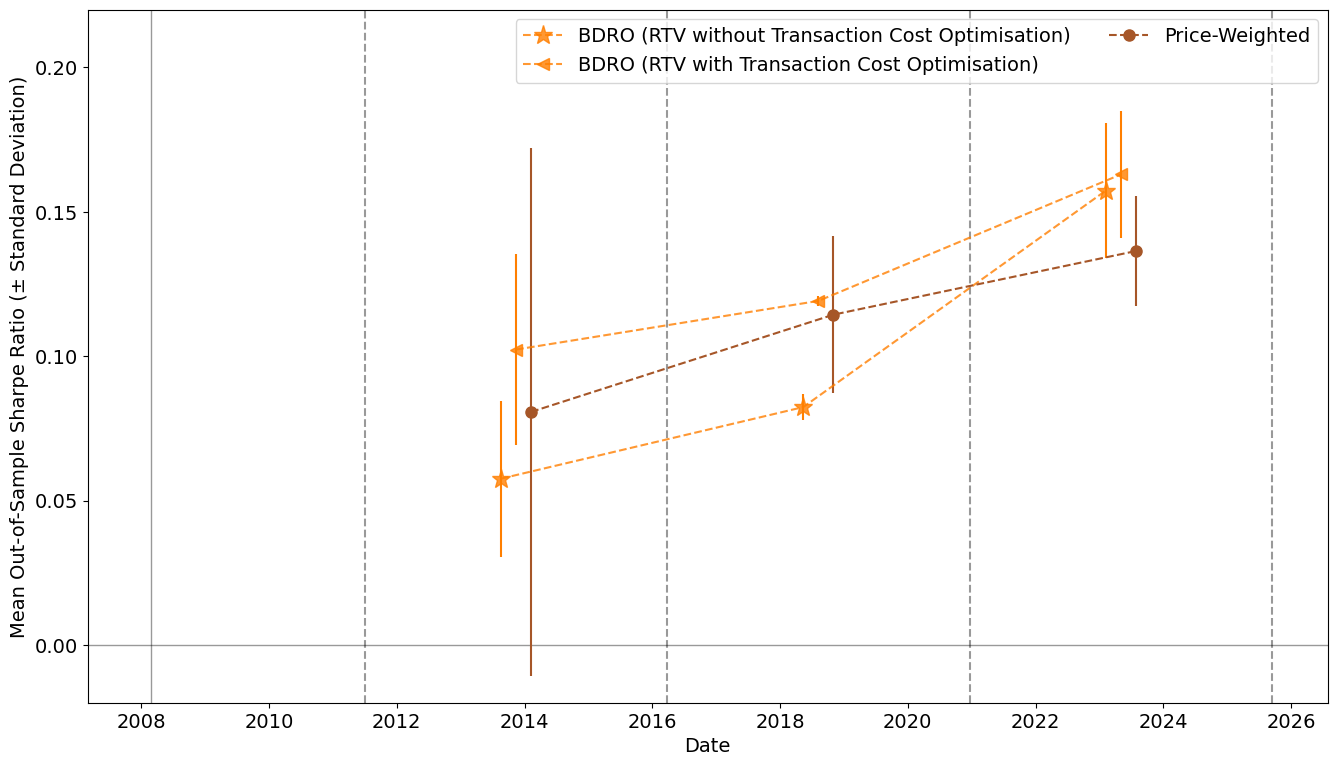

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

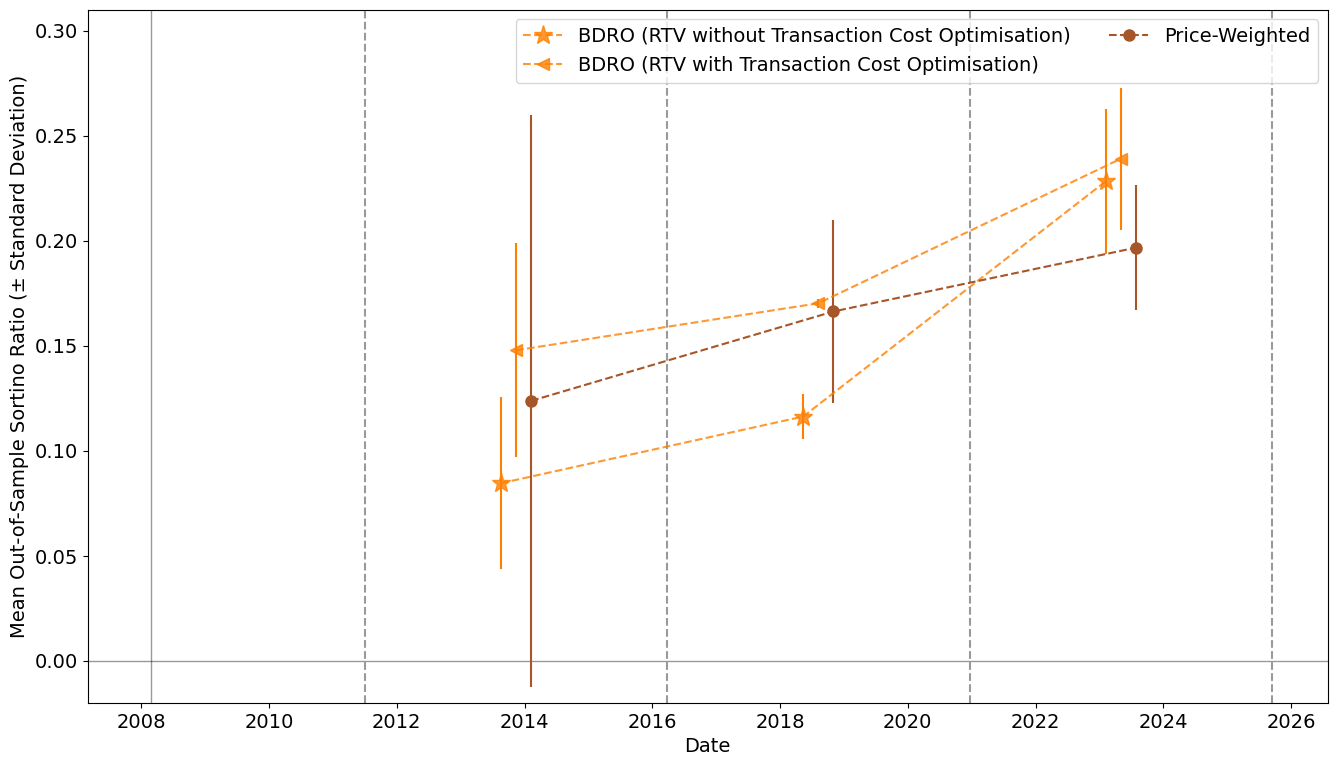

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

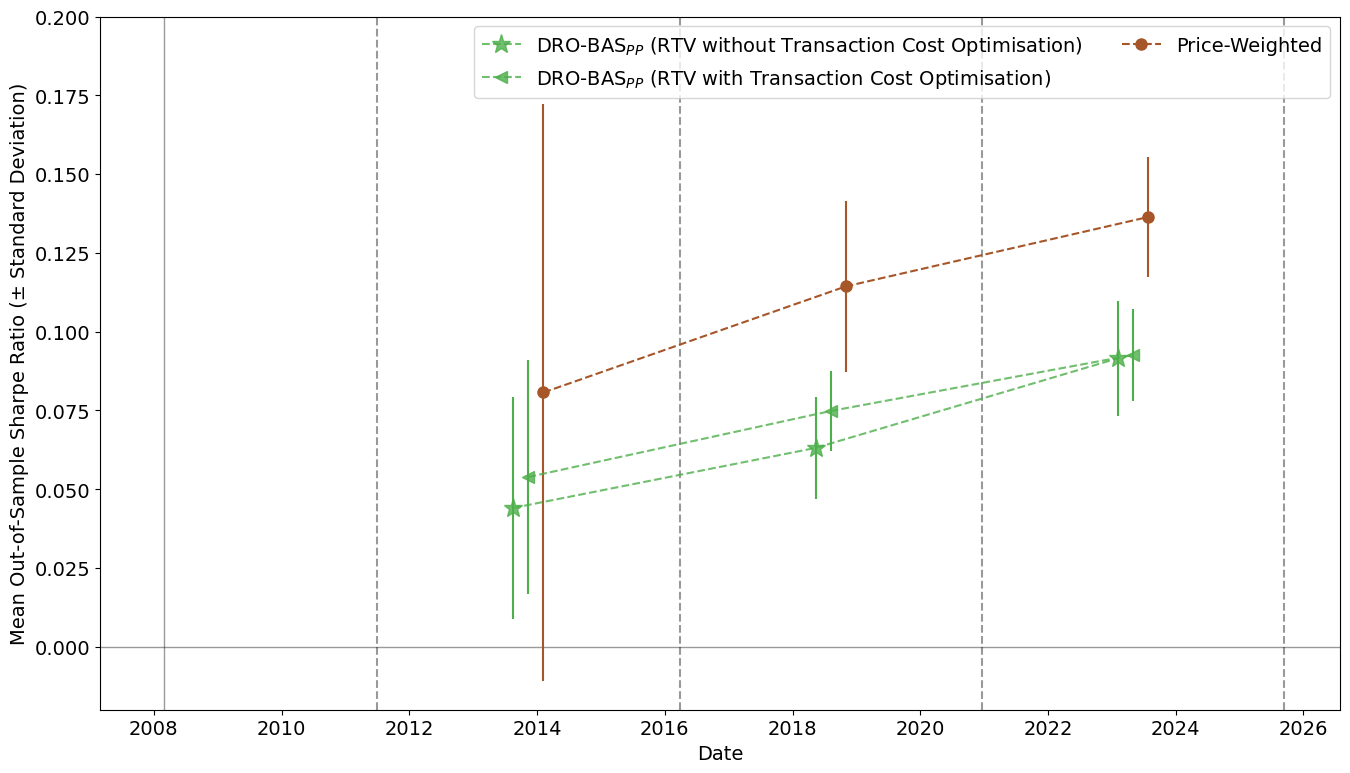

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

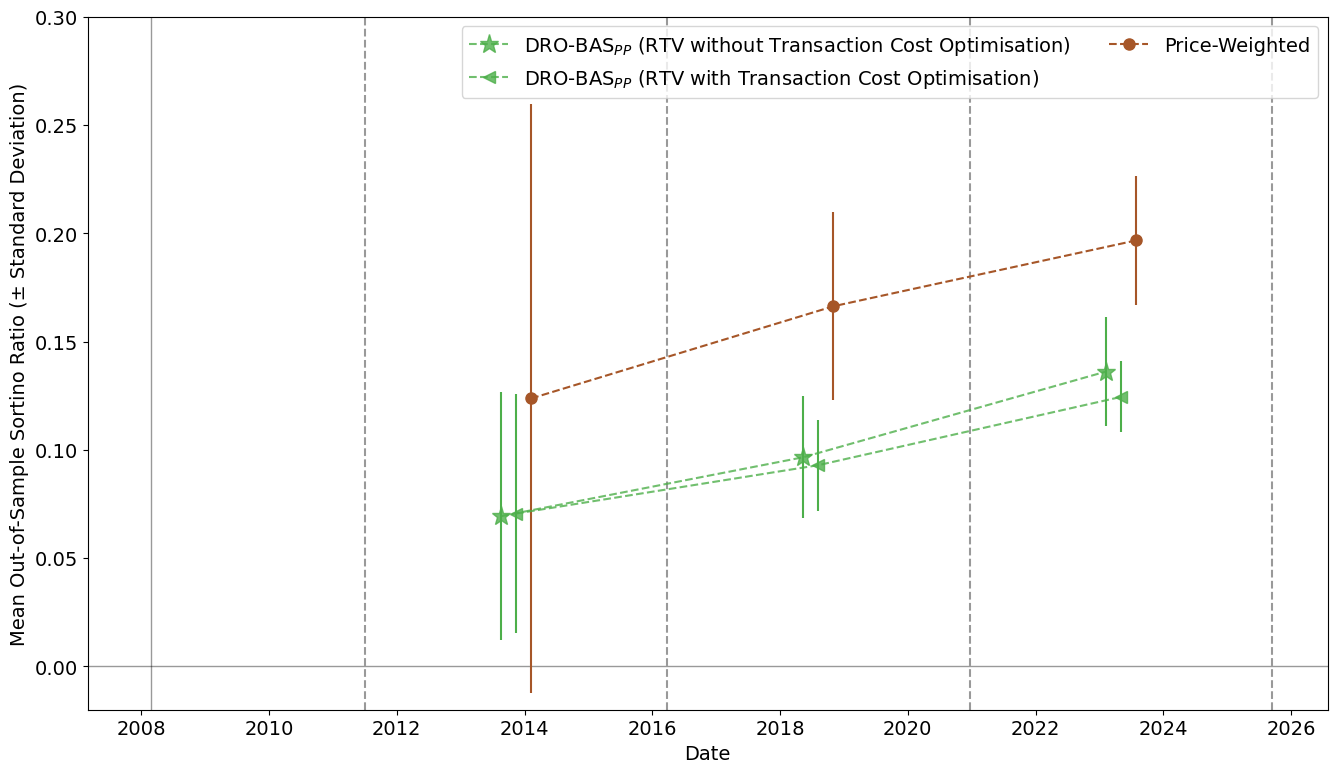

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

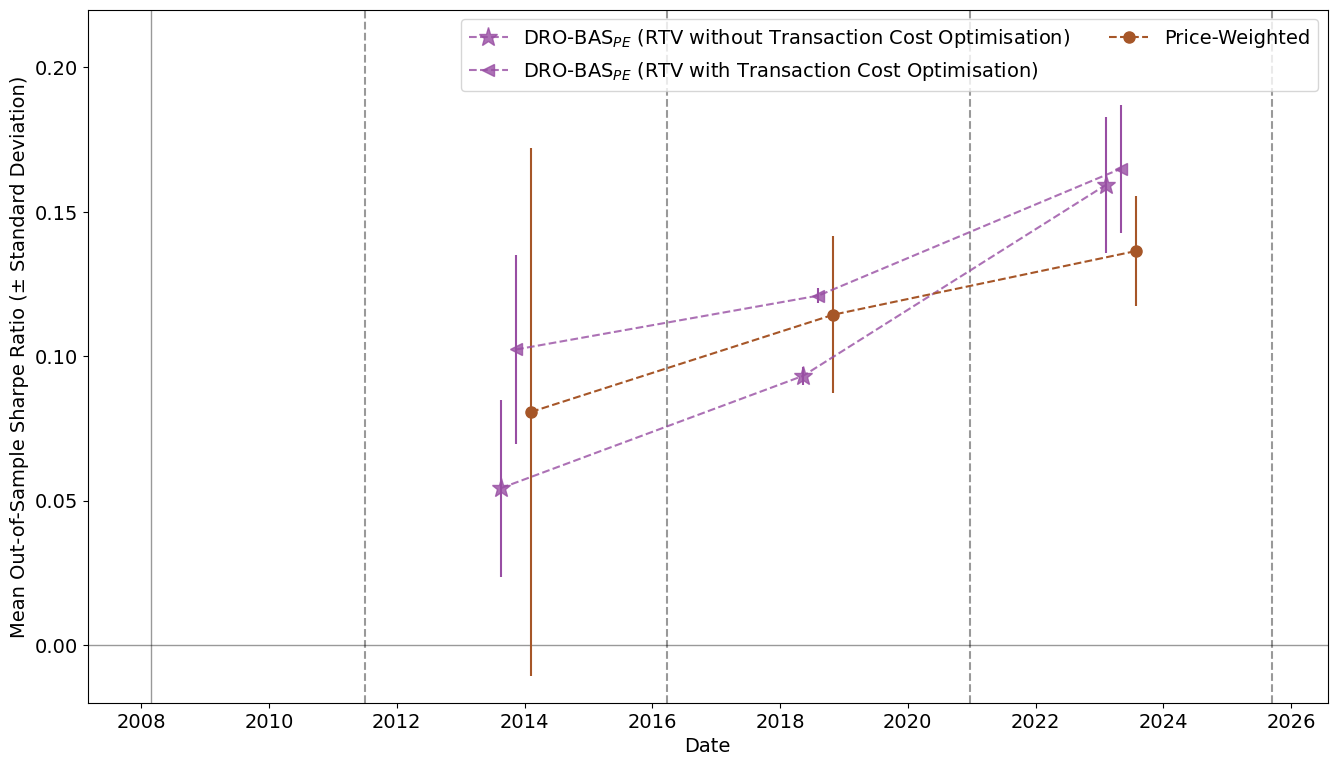

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

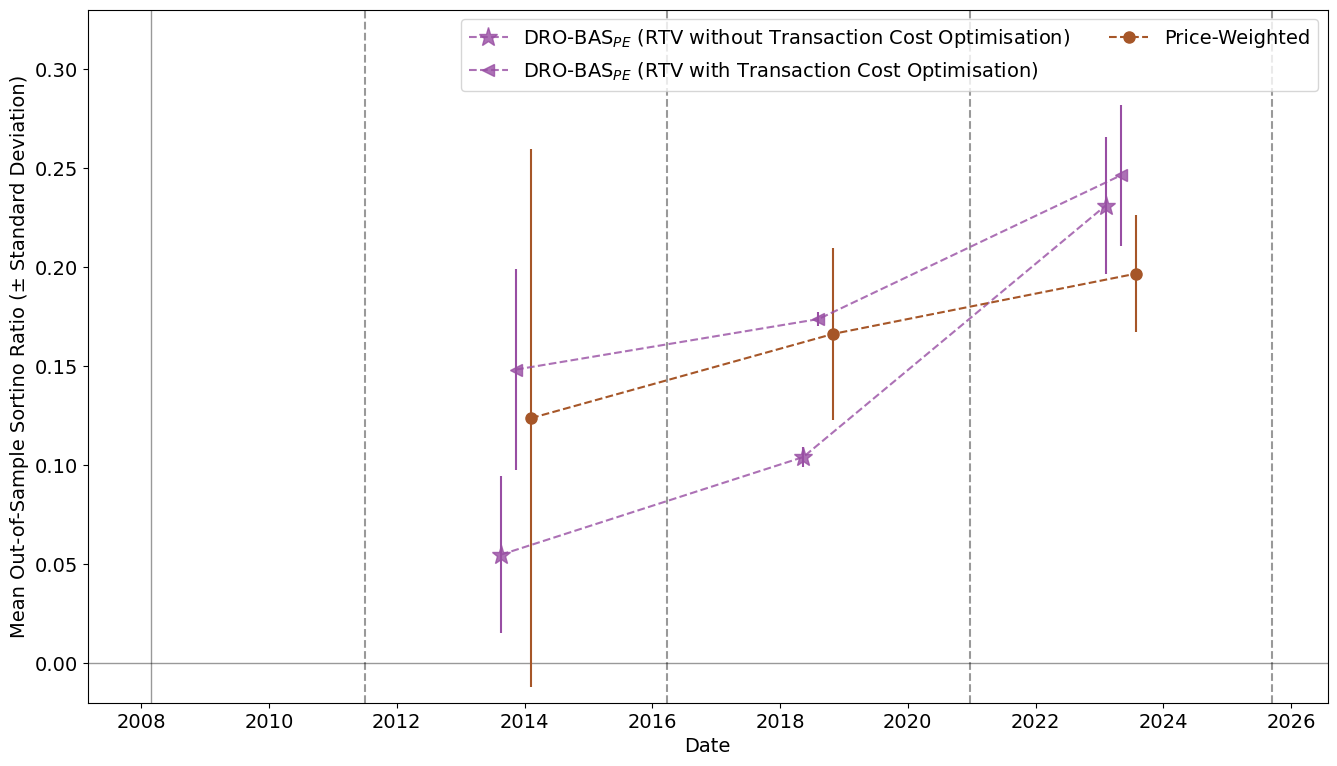

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

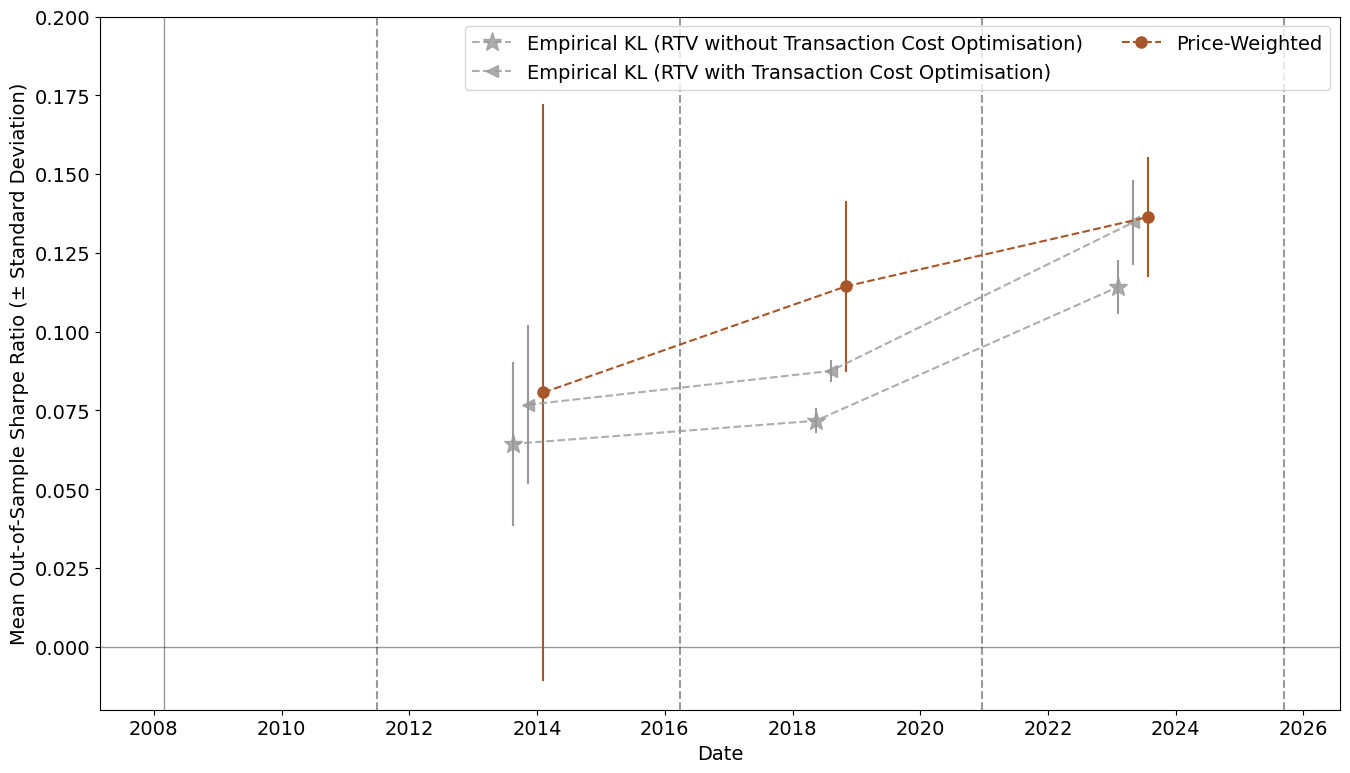

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

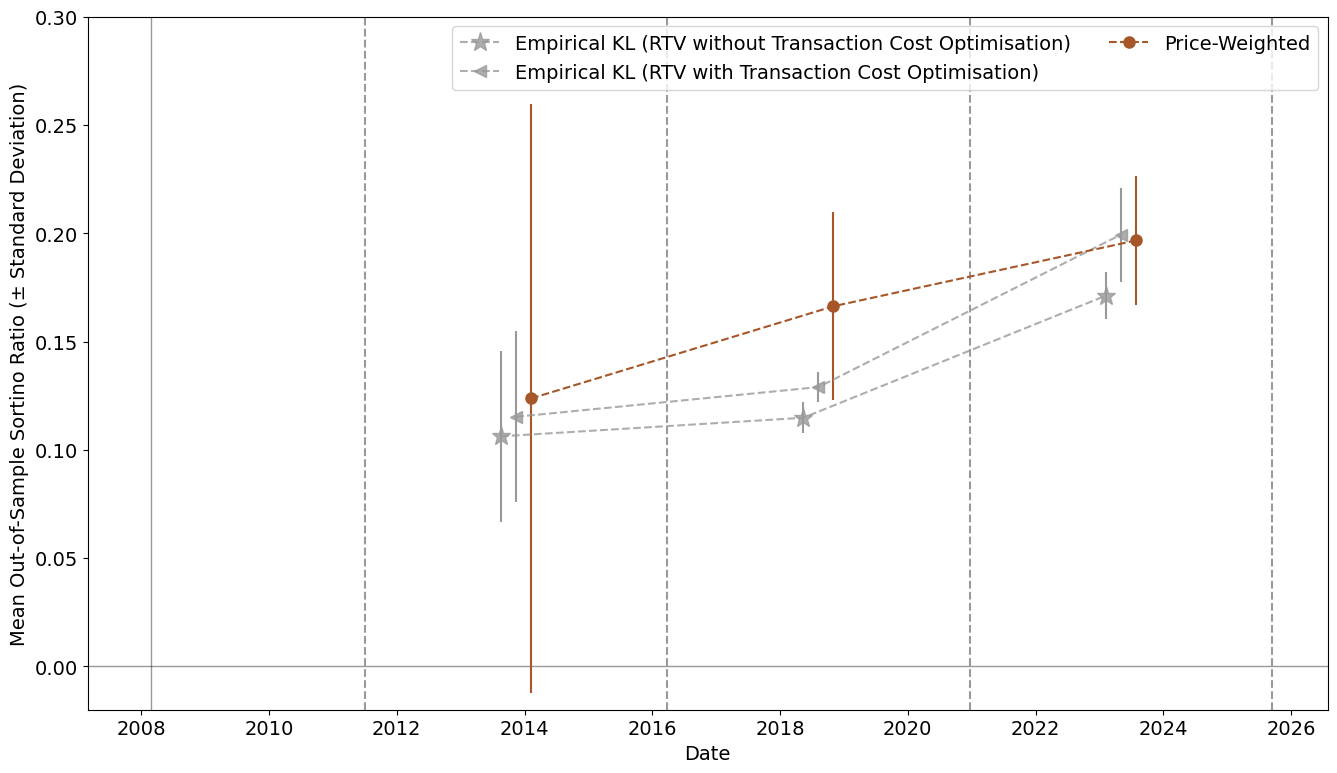

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

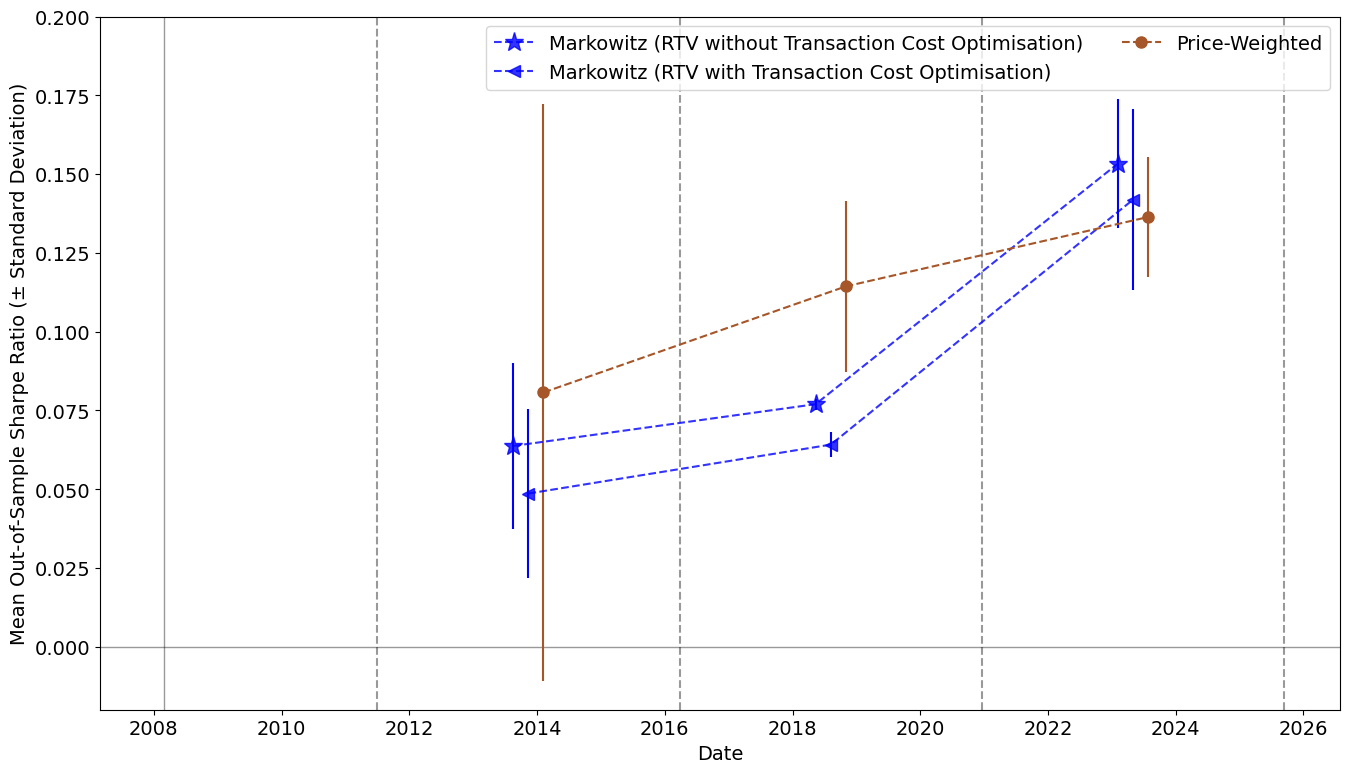

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

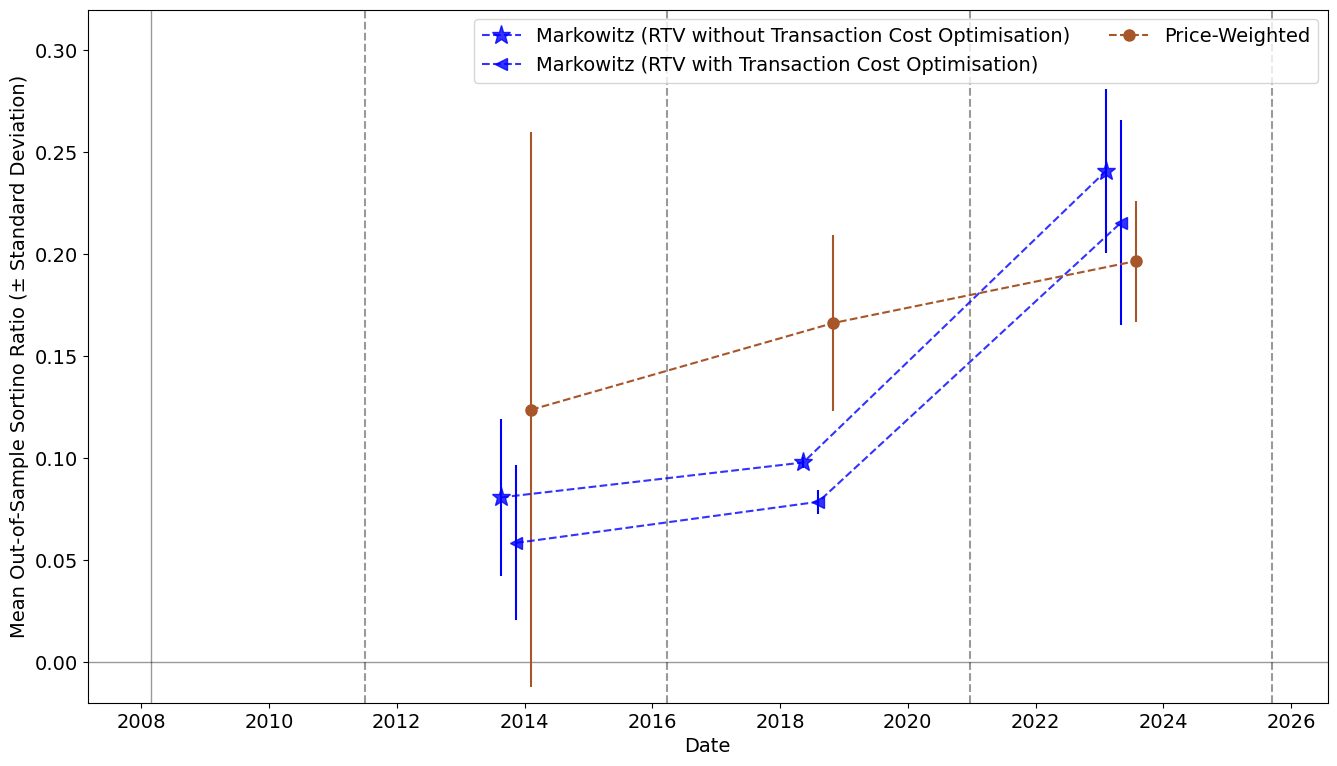

In [ ]:
# TODO (pwd): for all the below, you may have to change the dictionary values used to assing min_y and max_y, given the data change, the change in transaction cost calculation, how it's applied and the assumption of drifting portfolio weights in calculating the weekly portfolio returns

# if not include_transaction_costs:

#     # === NO TRANSACTION COSTS APPLIED TO RESULTS and NO WEIGHTING DRIFT ===
#     for algorithm in dro_algorithms_for_figure:
#         min_y, max_y = {
#             "kl_bdro": (-1.1, 2.7),
#             "kl_pp": (-1.1, 3.7),
#             "kl_dro_bas": (-1.1, 2.7),
#             "kl_empirical": (-1.1, 3),
#         }[algorithm]
#         plot_cumulative_returns_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, kl_experiment_dir_string, experiment_name, algorithm, dro_figure_data, kl_epsilon_list, AlgorithmName, AlgorithmColor, include_transaction_costs, save=False, min_y=min_y, max_y=max_y, has_weighting_drift=False)
#     # NOTE (pwd): above, pass False as the argument for has_weighting_drift
#     plot_cumulative_returns_for_markowitz_under_different_hyperparameters_against_portfolio_weighted_approach(include_transaction_costs, markowitz_normal_runs_figure_data, price_weighted_figure_data, markowitz_lambdas, save=False, min_y=-1.1, max_y=2.9, has_weighting_drift=False)
#     # NOTE (pwd): above, pass False as the argument for has_weighting_drift

#     # === NO TRANSACTION COSTS APPLIED TO RESULTS and WITH WEIGHTING DRIFT ===
#     # NOTE (pwd): duplicate the previous block except with True passed as the argument for has_weighting_drift
#     for algorithm in dro_algorithms_for_figure:
#         min_y, max_y = {
#             "kl_bdro": (-1.1, 2.7),
#             "kl_pp": (-1.1, 3.7),
#             "kl_dro_bas": (-1.1, 2.7),
#             "kl_empirical": (-1.1, 3),
#         }[algorithm]
#         plot_cumulative_returns_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, kl_experiment_dir_string, experiment_name, algorithm, dro_figure_data, kl_epsilon_list, AlgorithmName, AlgorithmColor, include_transaction_costs, save=False, min_y=min_y, max_y=max_y, has_weighting_drift=True)
#     plot_cumulative_returns_for_markowitz_under_different_hyperparameters_against_portfolio_weighted_approach(include_transaction_costs, markowitz_normal_runs_figure_data, price_weighted_figure_data, markowitz_lambdas, save=False, min_y=-1.1, max_y=2.9, has_weighting_drift=True)

# if include_transaction_costs:

#     # === TRANSACTION COSTS APPLIED TO RESULTS and WITH WEIGHTING DRIFT ===
#     for algorithm in dro_algorithms_for_figure:
#         min_y, max_y = {
#             "kl_bdro": (-1.2, 2.5),
#             "kl_pp": (-1.2, 2.2),
#             "kl_dro_bas": (-1.2, 2.5),
#             "kl_empirical": (-1.2, 2.9),
#         }[algorithm]
#         plot_cumulative_returns_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(price_weighted_figure_data, kl_experiment_dir_string, experiment_name, algorithm, dro_figure_data, kl_epsilon_list, AlgorithmName, AlgorithmColor, include_transaction_costs, save=False, min_y=min_y, max_y=max_y, has_weighting_drift=True)
#     # NOTE (pwd): above, pass True as the argument for has_weighting_drift
#     plot_cumulative_returns_for_markowitz_under_different_hyperparameters_against_portfolio_weighted_approach(include_transaction_costs, markowitz_normal_runs_figure_data, price_weighted_figure_data, markowitz_lambdas, save=False, min_y=-1.2, max_y=2.7, has_weighting_drift=True)
#     # NOTE (pwd): above, pass True as the argument for has_weighting_drift

# for ratio_type in ["sharpe", "sortino"]:
#     for algorithm in dro_algorithms_for_figure:
#         # min_y, max_y = {
#         #     "sharpe": {
#         #         "kl_bdro": (-0.06, 0.25),
#         #         "kl_pp": (-0.14, 0.24),
#         #         "kl_dro_bas": (-0.06, 0.25),
#         #         "kl_empirical": (-0.06, 0.21),
#         #     },
#         #     "sortino": {
#         #         "kl_bdro": (-0.08, 0.4),
#         #         "kl_pp": (-0.16, 0.39),
#         #         "kl_dro_bas": (-0.08, 0.4),
#         #         "kl_empirical": (-0.07, 0.34),
#         #     }
#         # }[ratio_type][algorithm]
#         min_y, max_y = {
#             "sharpe": {
#                 "kl_bdro": (-0.026, 0.204),
#                 "kl_pp": (-0.015, 0.195),
#                 "kl_dro_bas": (-0.005, 0.205),
#                 "kl_empirical": (-0.01, 0.18),
#             },
#             "sortino": {
#                 "kl_bdro": (-0.05, 0.33),
#                 "kl_pp": (-0.02, 0.29),
#                 "kl_dro_bas": (-0.01, 0.32),
#                 "kl_empirical": (-0.01, 0.28),
#             }
#         }[ratio_type][algorithm]
#         plot_ratios_for_one_dro_algorithm_under_different_hyperparameters_against_portfolio_weighted_approach(ratio_type, algorithm, kl_experiment_dir_string, experiment_name, include_transaction_costs, dro_figure_data, rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, weeks_for_risk_adjusted_metrics, num_test_weeks, kl_epsilon_list, False, min_y, max_y, plot_bands=True, band_x_data=band_x_data, band_dro_figure_data=band_dro_figure_data, dro_hyperparameters_to_marker=dro_hyperparameters_to_marker, dro_hyperparameters_to_jitter=dro_hyperparameters_to_jitter)
# for ratio_type in ["sharpe", "sortino"]:
#     # min_y, max_y = {
#     #     "sharpe": (-0.07, 0.24),
#     #     "sortino": (-0.09, 0.38)
#     # }[ratio_type]
#     min_y, max_y = {
#         "sharpe": (-0.06, 0.21),
#         "sortino": (-0.08, 0.33)
#     }[ratio_type]
#     plot_ratios_for_markowitz_under_different_hyperparameters_against_portfolio_weighted_approach(ratio_type, include_transaction_costs, markowitz_normal_runs_figure_data, rebalance_periods_for_risk_adjusted_metrics, weeks_for_risk_adjusted_metrics, num_test_weeks, markowitz_lambdas, False, min_y, max_y, plot_bands=True, band_x_data=band_x_data, band_markowitz_normal_runs_figure_data=band_markowitz_normal_runs_figure_data, markowitz_hyperparameters_to_marker=markowitz_hyperparameters_to_marker, markowitz_hyperparameters_to_jitter=markowitz_hyperparameters_to_jitter)

# for ratio_type in ("sharpe", "sortino"):
#     # min_y, max_y = {
#     #     "sharpe": (-0.04, 0.24),
#     #     "sortino": (-0.05, 0.4)
#     # }[ratio_type]
#     min_y, max_y = {
#         "sharpe": (-0.015, 0.22),
#         "sortino": (-0.015, 0.32)
#     }[ratio_type]
#     algorithm_best_hyperparameter_map = {
#         "sharpe": {
#             "kl_bdro": 1,
#             "kl_pp": 1,
#             "kl_dro_bas": 1,
#             "kl_empirical": 1,
#             "markowitz": 500
#         },
#         "sortino": {
#             "kl_bdro": 1,
#             "kl_pp": 1,
#             "kl_dro_bas": 1,
#             "kl_empirical": 1,
#             "markowitz": 500
#         }
#     }
#     plot_ratios_for_best_hyperparameters_against_price_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, dro_figure_data, markowitz_normal_runs_figure_data, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, algorithm_best_hyperparameter_map[ratio_type], AlgorithmName, AlgorithmColor, False, plot_bands=True, band_x_data=band_x_data, band_dro_figure_data=band_dro_figure_data, band_markowitz_normal_runs_figure_data=band_markowitz_normal_runs_figure_data, dro_hyperparameters_to_marker=dro_hyperparameters_to_marker, markowitz_hyperparameters_to_marker=markowitz_hyperparameters_to_marker, band_price_weighted_figure_data=band_price_weighted_figure_data)

# for ratio_type in ("sharpe", "sortino"):
#     min_y, max_y = {
#         "sharpe": (-0.04, 0.33),
#         "sortino": (-0.08, 0.63)
#     }[ratio_type]
#     plot_potential_ratios_for_dro_algorithms_and_markowitz_against_portfolio_weighted_approach(ratio_type, min_y, max_y, kl_experiment_dir_string, experiment_name, include_transaction_costs, potential_dro_ratio_results, potential_markowitz_ratio_results, AlgorithmName, AlgorithmColor, False, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics)

# for algorithm in dro_algorithms_for_figure:
#     for ratio_type in ("sharpe", "sortino"):
#         min_y, max_y = {
#             "sharpe": {
#                 "kl_bdro": (-0.09, 0.31),
#                 "kl_pp": (-0.06, 0.3),
#                 "kl_dro_bas": (-0.1, 0.31),
#                 "kl_empirical": (-0.1, 0.31),
#             },
#             "sortino": {
#                 "kl_bdro": (-0.11, 0.55),
#                 "kl_pp": (-0.07, 0.55),
#                 "kl_dro_bas": (-0.12, 0.56),
#                 "kl_empirical": (-0.12, 0.56),
#             }
#         }[ratio_type][algorithm]
#         # DRO SHV vs potential vs price-weighted
#         plot_ratios_for_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, algorithm, kl_validation_experiment_dirs_map["shv"][ratio_type], experiment_name_shv, True, potential_dro_ratio_results[ratio_type][algorithm]["highest_ratios"], rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, False, {"shv": shv_dro_figure_data})
# for ratio_type in ("sharpe", "sortino"):
#     min_y, max_y = {
#         "sharpe": (-0.07, 0.33),
#         "sortino": (-0.1, 0.63)
#     }[ratio_type]
#     # Markowitz SHV vs potential vs price-weighted
#     plot_ratios_for_validation_against_potential_ratios_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratio_results, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, {"shv": markowitz_shv_figure_data}, False)

# for ratio_type in (
#     "sharpe",
#     "sortino",
# ):
#     # min_y, max_y = {
#     #     "sharpe": (-0.09, 0.22),
#     #     "sortino": (-0.13, 0.39)
#     # }[ratio_type]
#     min_y, max_y = {
#         "sharpe": (-0.015, 0.21),
#         "sortino": (-0.03, 0.32)
#     }[ratio_type]
#     # SHV for DRO and Markowitz vs price-weighted
#     plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_validation_experiment_dirs_map["shv"][ratio_type], experiment_name_shv, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, shv_dro_figure_data, AlgorithmName, AlgorithmColor, markowitz_shv_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, "shv", False, plot_bands=plot_bands, band_x_data=band_x_data, band_validation_dro_figure_data=band_shv_dro_figure_data, band_markowitz_validation_figure_data=band_markowitz_shv_figure_data, band_price_weighted_figure_data=band_price_weighted_figure_data)

# for algorithm in dro_algorithms_for_figure:
#     for ratio_type in ("sharpe", "sortino"):
#         # min_y, max_y = {
#         #     "sharpe": {
#         #         "kl_bdro": (-0.09, 0.31),
#         #         "kl_pp": (-0.06, 0.3),
#         #         "kl_dro_bas": (-0.11, 0.31),
#         #         "kl_empirical": (-0.09, 0.3)
#         #     },
#         #     "sortino": {
#         #         "kl_bdro": (-0.11, 0.55),
#         #         "kl_pp": (-0.09, 0.55),
#         #         "kl_dro_bas": (-0.13, 0.56),
#         #         "kl_empirical": (-0.13, 0.58)
#         #     }
#         # }[ratio_type][algorithm]
#         min_y, max_y = {
#             "sharpe": {
#                 "kl_bdro": (-0.02, 0.3),
#                 "kl_pp": (-0.02, 0.22),
#                 "kl_dro_bas": (-0.02, 0.34),
#                 "kl_empirical": (-0.02, 0.34)
#             },
#             "sortino": {
#                 "kl_bdro": (-0.02, 0.5),
#                 "kl_pp": (-0.02, 0.37),
#                 "kl_dro_bas": (-0.02, 0.58),
#                 "kl_empirical": (-0.03, 0.59)
#             }
#         }[ratio_type][algorithm]
#         # DRO SHV vs rolling validation vs potential vs price-weighted
#         plot_ratios_for_validation_against_potential_ratios_for_one_dro_algorithm(ratio_type, algorithm, kl_validation_experiment_dirs_map["rolling_validation"][ratio_type], experiment_name_rolling_validation, True, potential_dro_ratio_results[ratio_type][algorithm]["highest_ratios"], rebalance_periods_for_risk_adjusted_metrics, AlgorithmName, AlgorithmColor, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, price_weighted_figure_data, False, {"shv": shv_dro_figure_data, "rolling_validation": rolling_validation_dro_figure_data}, plot_bands=plot_bands, band_x_data=band_x_data, band_potential_dro_ratio_results=band_potential_dro_ratio_results[ratio_type][algorithm]["highest_ratios"], band_price_weighted_figure_data=band_price_weighted_figure_data, band_dro_validation_figure_data={"shv": band_shv_dro_figure_data, "rolling_validation": band_rolling_validation_dro_figure_data})
# for ratio_type in ("sharpe", "sortino"):
#     # min_y, max_y = {
#     #     "sharpe": (-0.07, 0.33),
#     #     "sortino": (-0.1, 0.63)
#     # }[ratio_type]
#     min_y, max_y = {
#         "sharpe": (-0.02, 0.41),
#         "sortino": (-0.03, 0.76)
#     }[ratio_type]
#     # Markowitz SHV vs rolling validation vs potential vs price-weighted
#     plot_ratios_for_validation_against_potential_ratios_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, potential_markowitz_ratio_results, price_weighted_figure_data, rebalance_periods_for_risk_adjusted_metrics, {"shv": markowitz_shv_figure_data, "rolling_validation": markowitz_rolling_validation_figure_data}, False, plot_bands=plot_bands, band_x_data=band_x_data, band_potential_markowitz_ratio_results=band_potential_markowitz_ratio_results[ratio_type]["highest_ratios"], band_price_weighted_figure_data=band_price_weighted_figure_data, band_markowitz_validation_figure_data={"shv": band_markowitz_shv_figure_data, "rolling_validation": band_markowitz_rolling_validation_figure_data})

# for ratio_type in (
#     "sharpe",
#     "sortino",
# ):
#     # min_y, max_y = {
#     #     "sharpe": (-0.11, 0.22),
#     #     "sortino": (-0.13, 0.34)
#     # }[ratio_type]
#     min_y, max_y = {
#         "sharpe": (-0.02, 0.21),
#         "sortino": (-0.02, 0.32)
#     }[ratio_type]
#     # Rolling validation (without tcost optimisation) for DRO and Markowitz vs price-weighted
#     plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_validation_experiment_dirs_map["rolling_validation"][ratio_type], experiment_name_rolling_validation, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, rolling_validation_dro_figure_data, AlgorithmName, AlgorithmColor, markowitz_rolling_validation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, "rolling_validation", False, plot_bands=plot_bands, band_x_data=band_x_data, band_validation_dro_figure_data=band_rolling_validation_dro_figure_data, band_markowitz_validation_figure_data=band_markowitz_rolling_validation_figure_data, band_price_weighted_figure_data=band_price_weighted_figure_data)

for algorithm in dro_algorithms_for_figure:
    for ratio_type in ("sharpe", "sortino"):
        min_y, max_y = {
            "sharpe": {
                "kl_bdro": (-0.02, 0.22),
                "kl_pp": (-0.02, 0.2),
                "kl_dro_bas": (-0.02, 0.22),
                "kl_empirical": (-0.02, 0.2)
            },
            "sortino": {
                "kl_bdro": (-0.02, 0.31),
                "kl_pp": (-0.02, 0.3),
                "kl_dro_bas": (-0.02, 0.33),
                "kl_empirical": (-0.02, 0.3)
            }
        }[ratio_type][algorithm]
        # DRO rolling validation with vs without tcost optimisation vs price-weighted
        plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_one_dro_algorithm(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, rolling_validation_dro_figure_data, rolling_validation_dro_figure_data_tcost_optimisation, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, algorithm, kl_validation_experiment_dirs_map_tcost_optimisation["rolling_validation"][ratio_type], AlgorithmName, AlgorithmColor, plot_bands=plot_bands, band_x_data=band_x_data, band_rolling_validation_dro_figure_data=band_rolling_validation_dro_figure_data, band_rolling_validation_dro_figure_data_tcost_optimisation=band_rolling_validation_dro_figure_data_tcost_optimisation, band_price_weighted_figure_data=band_price_weighted_figure_data)
for ratio_type in (
    "sharpe",
    "sortino",
):
    min_y, max_y = {
        "sharpe": (-0.02, 0.2),
        "sortino": (-0.02, 0.32)
    }[ratio_type]
    # Markowitz rolling validation with vs without tcost optimisation vs price-weighted
    plot_ratios_for_rolling_validation_with_and_without_transaction_cost_optimisation_for_markowitz(ratio_type, min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, markowitz_rolling_validation_figure_data, markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, plot_bands=plot_bands, band_x_data=band_x_data, band_markowitz_rolling_validation_figure_data=band_markowitz_rolling_validation_figure_data, band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data=band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, band_price_weighted_figure_data=band_price_weighted_figure_data)

# for ratio_type in (
#     "sharpe",
#     "sortino",
# ):
#     min_y, max_y = {
#         "sharpe": (-0.01, 0.24),
#         "sortino": (-0.07, 0.38)
#     }[ratio_type]
#     # Rolling validation with tcost optimisation for DRO and Markowitz vs price-weighted
#     plot_ratios_for_validation_for_dro_and_markowitz_against_price_weighted_approach(ratio_type, kl_validation_experiment_dirs_map_tcost_optimisation["rolling_validation"][ratio_type], "", min_y, max_y, weeks_for_risk_adjusted_metrics, num_test_weeks, dro_algorithms_for_figure, rolling_validation_dro_figure_data_tcost_optimisation, AlgorithmName, AlgorithmColor, markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, rebalance_periods_for_risk_adjusted_metrics, price_weighted_figure_data, False, "rolling_validation", True, plot_bands=plot_bands, band_x_data=band_x_data, band_validation_dro_figure_data=band_rolling_validation_dro_figure_data_tcost_optimisation, band_markowitz_validation_figure_data=band_markowitz_rolling_validation_with_transaction_cost_optimisation_figure_data, band_price_weighted_figure_data=band_price_weighted_figure_data)

# # TODO: complete the rest of the functions and call them here

In [19]:
if compare_with_original:

    cumulative_returns_plot_data_dict = {}

    for line in ax.get_lines():

        cumulative_returns_plot_data_dict[line.get_label()] = {
            "x": line.get_xdata(),
            "y": line.get_ydata()
        }

    directory_with_old_plot_data_for_replication = "/dcs/pg24/u5674159/mis-dro-code/james_old_plot_data_for_replication"
    with open(f"{directory_with_old_plot_data_for_replication}/cumulative_returns_bdro_dro-bas_real_data.pkl", "rb") as f:
        old_cumulative_returns_plot_data_dict = pickle.load(f)

    assert old_cumulative_returns_plot_data_dict.keys() == cumulative_returns_plot_data_dict.keys()
    for key in old_cumulative_returns_plot_data_dict:
        for coord in "x", "y":
            np.array_equal(old_cumulative_returns_plot_data_dict[key][coord], cumulative_returns_plot_data_dict[key][coord])

In [20]:
epsilon_filtered_results_df = results_df[results_df["epsilon"].isin(kl_epsilon_list)]

time_df = get_agg_df(
    epsilon_filtered_results_df,
    ["algorithm", "epsilon"]
)[["mean_solve_time", "std_solve_time", "mean_sample_time", "std_sample_time"]]

# print(time_df)

decimal_places = 3  # TODO: dynamically load this into the format strings below, if possible
time_df["str_sample_time"] = time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: "{:.3f}".format(np.round(10**2 * x["mean_sample_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(10**2 * x["std_sample_time"], decimal_places)) + ")", axis=1
)

time_df["str_solve_time"] = time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: "{:.3f}".format(np.round(x["mean_solve_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(x["std_solve_time"], decimal_places)) + ")", axis=1
)

print(time_df)

time_df = time_df.reindex(["kl_dro_bas", "kl_pp", "kl_bdro", "kl_empirical"])
time_df.index = time_df.index.map(lambda x: AlgorithmName[x].value)
# print(time_df[["str_solve_time", "str_sample_time"]].to_latex())

for risk_aversion in list(markowitz_results_james_normal_runs.keys()):
    solve_times = [window['solve_time'] for window in markowitz_results_james_normal_runs[risk_aversion]]
    print(f'For a lambda of {risk_aversion}, mean and std of solve times (s) are {np.mean(solve_times)} and {np.std(solve_times)} respectively.')

                      mean_solve_time  std_solve_time  mean_sample_time  \
algorithm    epsilon                                                      
kl_bdro      0.00001         3.168987        0.169049          0.028260   
             0.00100         3.178526        0.158713          0.029079   
             1.00000         3.184405        0.167354          0.028864   
kl_dro_bas   0.00001         0.012452        0.021020          0.000359   
             0.00100         0.012408        0.020841          0.000348   
             1.00000         0.012039        0.021317          0.000363   
kl_empirical 0.00001         0.026671        0.021499          0.000019   
             0.00100         0.023398        0.021475          0.000021   
             1.00000         0.025048        0.021600          0.000020   
kl_pp        0.00001         2.058250        0.248712          0.003711   
             0.00100         1.606182        0.068713          0.003464   
             1.00000     

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function mean at 0x7facf82e4f40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function std at 0x7facf82e5080> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(**agg_dict)


In [21]:
# TODO: refactor with previous cell

def print_times_for_kl_dro_with_validation(ratio_type_to_results_df_map) -> None:

    kl_results_both_ratios_df = pd.concat(list(ratio_type_to_results_df_map.values()))
    time_df = get_agg_df(kl_results_both_ratios_df, ["algorithm"], temporal_validation=True)[["mean_total_solve_time", "std_total_solve_time", "mean_total_sample_time", "std_total_sample_time"]]

    decimal_places = 3
    time_df["str_total_sample_time"] = time_df[["mean_total_sample_time", "std_total_sample_time"]].apply(
        lambda x: "{:.3f}".format(np.round(10**2 * x["mean_total_sample_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(10**2 * x["std_total_sample_time"], decimal_places)) + ")", axis=1
    )

    time_df["str_total_solve_time"] = time_df[["mean_total_solve_time", "std_total_solve_time"]].apply(
        lambda x: "{:.3f}".format(np.round(x["mean_total_solve_time"], decimal_places)) + " (" + "{:.3f}".format(np.round(x["std_total_solve_time"], decimal_places)) + ")", axis=1
    )

    print(time_df)

def print_times_for_markowitz_with_validation(markowitz_results_validation_with_tcosts_in_results) -> None:

    markowitz_windows_both_ratios = markowitz_results_validation_with_tcosts_in_results["sharpe"] + markowitz_results_validation_with_tcosts_in_results["sortino"]
    markowitz_total_solve_times = [window["total_solve_time_hyperparameter_optimisation_and_final_run"] for window in markowitz_windows_both_ratios]
    
    print(f'For Markowitz, mean and std of solve times (s) are {np.mean(markowitz_total_solve_times)} and {np.std(markowitz_total_solve_times)} respectively.\n')

if james_windows:

    print("\n=== SINGLE HOLDOUT VALIDATION ===\n")

    print_times_for_kl_dro_with_validation(ratio_type_to_kl_validation_results_df_maps["shv"])

    print_times_for_markowitz_with_validation(markowitz_results_shv_with_tcosts_in_results)


    print("\n=== ROLLING TEMPORAL VALIDATION WITHOUT TRANSACTION COST OPTIMISATION ===\n")

    print_times_for_kl_dro_with_validation(ratio_type_to_kl_validation_results_df_maps["rolling_validation"])

    print_times_for_markowitz_with_validation(markowitz_results_rolling_validation_with_tcosts_in_results)


    print("\n=== ROLLING TEMPORAL VALIDATION WITH TRANSACTION COST OPTIMISATION ===\n")

    print_times_for_kl_dro_with_validation(ratio_type_to_kl_validation_results_df_maps_tcost_optimisation["rolling_validation"])

    print_times_for_markowitz_with_validation(markowitz_results_rolling_validation_with_tcosts_in_results_and_cost_function)

/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function mean at 0x7facf82e4f40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function std at 0x7facf82e5080> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dro-code/mis_dro/plot.py:249: FutureWarning: The provided callable <function mean at 0x7facf82e4f40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(**agg_dict)
/dcs/pg24/u5674159/mis-dr


=== SINGLE HOLDOUT VALIDATION ===

              mean_total_solve_time  std_total_solve_time  \
algorithm                                                   
kl_bdro                   12.365024              0.633197   
kl_dro_bas                 0.044714              0.053058   
kl_empirical               0.090825              0.044862   
kl_pp                      6.903473              0.395230   

              mean_total_sample_time  std_total_sample_time  \
algorithm                                                     
kl_bdro                     0.112777               0.006251   
kl_dro_bas                  0.001506               0.001586   
kl_empirical                0.000077               0.000014   
kl_pp                       0.013500               0.006905   

             str_total_sample_time str_total_solve_time  
algorithm                                                
kl_bdro             11.278 (0.625)       12.365 (0.633)  
kl_dro_bas           0.151 (0.159)        0.